<a href="https://colab.research.google.com/github/TatkovDmitriy/-/blob/main/%D0%9B%D0%B8%D0%B4%D0%BE%D0%B3%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U -q PyDrive
# 📦 Загрузка библиотек для анализа данных

# Работа с таблицами и массивами
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
# Настройки визуализации
plt.style.use('ggplot')  # безопасная альтернатива, встроенная в matplotlib
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_palette('Set2')

# Статистика и A/B-тесты
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Работа с датами
import datetime as dt
from google.colab import auth
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from oauth2client.client import GoogleCredentials

# 📥 Импорт
from phik import resources, report
from phik.report import plot_correlation_matrix

# Отображение и подавление предупреждений
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
print("библиотеки загружены")

In [ ]:
# Авторизация
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Заменяем file_id на свой
file_id = '1ER-MhDJ4s-M8MNQXKeLy2YgzDoW92drD'
downloaded = drive.CreateFile({'id': file_id})
downloaded.GetContentFile('lead.csv')  # сохраняем под нужным названием

# ✅ Читаем файл с правильным разделителем (точно ';')
data = pd.read_csv('lead.csv', sep=';', encoding='utf-8', on_bad_lines='skip')

# Выводим preview
display("Первые строки данных:")
display(data.head(10))

display("Информация о данных:")
display(data.info())


'Первые строки данных:'

,Тип проекта,Тип под проекта,object_id,Магазин,Время создания,Время завершения,Реакция на лид,Статус завершения,Причина отмены,Источник лида,...,Подразделение создателя лида,Магазин создателя лида,Лид обработал,Подразделение обработавшего лид,"GMV сделки, ₽",Статус сделки,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Ванные,Ванные,6776306289a43e7828130149,37 - Красноярск 2,02.01.2025,02.01.2025,"8,69",Создана сделка,NaN,LM_WORK,...,сантехника,37 - Красноярск 2,60059734-Мадиярова Гульфия,настенная и напольная плитка,186 456,Завершена,NaN,https://clientprojects.lemanapro.ru/presales/1...,NaN,NaN
1,ИС,Системы фильтрации воды,6776c5a989a43e7828130239,46 - Казань Солнечный,02.01.2025,03.01.2025,"790,91",Создана сделка,NaN,LM_WORK,...,дирекция,46 - Казань Солнечный,60136375-Урманов Ильдар,водоканализационные системы - отопление,2600,Завершена,NaN,https://clientprojects.lemanapro.ru/presales/b...,NaN,NaN
2,Кухни,Кухни,6777976689a43e78281302a2,46 - Казань Солнечный,03.01.2025,03.01.2025,"6,91",Создана сделка,NaN,LM_WORK,...,настенная и напольная плитка,46 - Казань Солнечный,60228556-Кодиров Тимурлан,кухни,0,Отменена,NaN,https://clientprojects.lemanapro.ru/presales/e...,Конфигурация не найдена,NaN
3,Ванные,Ванные,6777806989a43e7828130276,109 - Пермь,03.01.2025,03.01.2025,"1,11",Создана сделка,NaN,LM_WORK,...,сантехника,109 - Пермь,60132380-Буторина Алёна,настенная и напольная плитка,99 537,Завершена,NaN,https://clientprojects.lemanapro.ru/presales/f...,NaN,NaN
4,Ванные,Ванные,67776a04b4f8d152a2ec4363,89 - Барнаул 2,03.01.2025,03.01.2025,"17,57",Создана сделка,NaN,LM_WORK,...,сад,89 - Барнаул 2,60212310-Липинская Анна,настенная и напольная плитка,0,Отменена,NaN,https://clientprojects.lemanapro.ru/presales/0...,Конфигурация не найдена,NaN
5,ИС,Электроснабжение,67776a552d7298342f45be74,89 - Барнаул 2,03.01.2025,04.01.2025,"1522,23",Отменен,Не интересно,LM_WORK,...,сад,89 - Барнаул 2,60225941-Кондратьева Алина,водоканализационные системы - отопление,NaN,NaN,NaN,NaN,NaN,NaN
6,ИС,Отопление и водоснабжение,67776a80b4f8d152a2ec4364,89 - Барнаул 2,03.01.2025,09.01.2025,"8819,54",Отменен,Не интересно,LM_WORK,...,сад,89 - Барнаул 2,60100323-Рябыкина Елена,водоканализационные системы - отопление,NaN,NaN,NaN,NaN,NaN,NaN
7,Столярка,Терассы,6777cd982d7298342f45bf25,153 - Жуковский,03.01.2025,03.01.2025,"1,07",Создана сделка,NaN,LM_WORK,...,освещение,153 - Жуковский,60067084-Муслимова Фатма,столярные изделия,"35106,93",Завершена,NaN,https://clientprojects.lemanapro.ru/presales/d...,В сделке оплачен только один артикул,NaN
8,Кухни,Кухни,6777ef4b89a43e7828130375,46 - Казань Солнечный,03.01.2025,03.01.2025,"14,03",Создана сделка,NaN,LM_WORK,...,сантехника,46 - Казань Солнечный,60039028-Талипова Кристина,кухни,0,Отменена,NaN,https://clientprojects.lemanapro.ru/presales/4...,Конфигурация не найдена,NaN
9,Ванные,Ванные,6777ef74b4f8d152a2ec446a,46 - Казань Солнечный,03.01.2025,03.01.2025,"98,6",Отменен,Другое,LM_WORK,...,сантехника,46 - Казань Солнечный,60213163-Кубанычбекова Гулиза,настенная и напольная плитка,NaN,NaN,NaN,NaN,NaN,NaN


'Информация о данных:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310888 entries, 0 to 310887
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Тип проекта                      310888 non-null  object
 1   Тип под проекта                  310888 non-null  object
 2   object_id                        310888 non-null  object
 3   Магазин                          310888 non-null  object
 4   Время создания                   310888 non-null  object
 5   Время завершения                 310888 non-null  object
 6   Реакция на лид                   310888 non-null  object
 7   Статус завершения                310888 non-null  object
 8   Причина отмены                   99830 non-null   object
 9   Источник лида                    310888 non-null  object
 10  Канал                            288876 non-null  object
 11  Лид создан                       310888 non-null  object
 12  Должность создат

None

# 🧾 Описание данных по лидам (Lemana PRO)

Набор данных содержит информацию о 150 002 лидах, созданных в различных направлениях бизнеса (кухни, ванные, стройка и др.). Каждая строка соответствует одному лиду и содержит характеристики обработки, статуса, источника, а также привязку к магазину и сотрудникам.

## 📌 Структура данных

| Колонка | Описание |
|--------|----------|
| **Тип проекта** | Направление сделки (например, Кухни, Ванные, Стройка) |
| **Тип под проекта** | Подкатегория внутри направления (например, Стены, Полы) |
| **object_id** | Уникальный идентификатор лида |
| **Магазин** | Название и номер магазина, где создан или обработан лид |
| **Время создания** | Локальное время создания лида |
| **Время завершения** | Локальное время завершения обработки лида |
| **Реакция на лид** | Время реакции на лид в минутах |
| **Статус завершения** | Итоговая обработка лида: «Создана сделка», «Отменен», «Недозвон» и т.д. |
| **Причина отмены** | Указанная причина отмены (если статус — «Отменен») |
| **Источник лида** | Канал поступления лида (лендинг, замер, конфигуратор и др.) |
| **Канал** | Подканал или источник генерации, если доступен |
| **Лид создан** | Техническая информация о создателе лида |
| **Должность создателя лида** | Должность сотрудника, создавшего лид |
| **Подразделение создателя лида** | Подразделение, к которому относится создатель |
| **Магазин создателя лида** | Магазин, где работает создатель лида |
| **Лид обработал** | Имя или LDAP сотрудника, обработавшего лид |
| **Подразделение обработавшего лид** | Подразделение обработчика |
| **GMV сделки, ₽** | Сумма оборота (если лид перешёл в сделку) |
| **Статус сделки** | Статус сделки: Завершена, Отменена и т.д. (если была создана) |

## ⚠️ Особенности

- Временные поля указаны в строковом формате и требуют преобразования в `datetime`.
- GMV указана как строка с пробелами и должна быть приведена к `float`.
- Многие поля содержат пропущенные значения (`NaN`), особенно по отменённым лидам.
- Учитываются исключения (тестовые сделки, сделки без товаров и т.д.) согласно методологии отчёта.

---


In [ ]:
# 🧹 Приведение названий столбцов к стилю snake_case

# Вывод текущих названий столбцов
display("### Текущие названия столбцов:")
display(data.columns.tolist())

# Приведение названий к нижнему регистру и стилю snake_case
data.columns = data.columns.str.lower().str.replace(' ', '_')

# Вывод обновлённых названий столбцов
display("### Обновлённые названия столбцов:")
display(data.columns.tolist())


'### Текущие названия столбцов:'

['Тип проекта',
 'Тип под проекта',
 'object_id',
 'Магазин',
 'Время создания',
 'Время завершения',
 'Реакция на лид',
 'Статус завершения',
 'Причина отмены',
 'Источник лида',
 'Канал',
 'Лид создан',
 'Должность создателя лида',
 'Подразделение создателя лида',
 'Магазин создателя лида',
 'Лид обработал',
 'Подразделение обработавшего лид',
 'GMV сделки, ₽',
 'Статус сделки',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22']

'### Обновлённые названия столбцов:'

['тип_проекта',
 'тип_под_проекта',
 'object_id',
 'магазин',
 'время_создания',
 'время_завершения',
 'реакция_на_лид',
 'статус_завершения',
 'причина_отмены',
 'источник_лида',
 'канал',
 'лид_создан',
 'должность_создателя_лида',
 'подразделение_создателя_лида',
 'магазин_создателя_лида',
 'лид_обработал',
 'подразделение_обработавшего_лид',
 'gmv_сделки,_₽',
 'статус_сделки',
 'unnamed:_19',
 'unnamed:_20',
 'unnamed:_21',
 'unnamed:_22']

In [ ]:
# 🔍 Проверка типов данных и преобразование

# Вывод текущих типов данных
display("### Типы данных до преобразования:")
display(data.dtypes)

# Примеры значений в ключевых столбцах, нуждающихся в преобразовании
display("### Примеры значений для анализа:")
display(data[['время_создания', 'время_завершения', 'gmv_сделки,_₽']].head(10))

# Преобразование временных столбцов в datetime
data['время_создания'] = pd.to_datetime(data['время_создания'], errors='coerce', dayfirst=True)
data['время_завершения'] = pd.to_datetime(data['время_завершения'], errors='coerce', dayfirst=True)

# Преобразование GMV: строка → float (удаляем пробелы, заменяем запятую на точку, если потребуется)
data['gmv_сделки,_₽'] = (
    data['gmv_сделки,_₽']
    .astype(str)
    .str.replace(' ', '', regex=False)
    .str.replace(',', '.', regex=False)
    .replace('nan', np.nan)
)
data['gmv_сделки,_₽'] = pd.to_numeric(data['gmv_сделки,_₽'], errors='coerce')

# Проверка типов данных после преобразования
display("### Типы данных после преобразования:")
display(data.dtypes)

# Подсчёт пропусков
display("### Количество пропусков после преобразования:")
display(data.isnull().sum())


'### Типы данных до преобразования:'

,0
тип_проекта,object
тип_под_проекта,object
object_id,object
магазин,object
время_создания,object
время_завершения,object
реакция_на_лид,object
статус_завершения,object
причина_отмены,object
источник_лида,object


'### Примеры значений для анализа:'

,время_создания,время_завершения,"gmv_сделки,_₽"
0,02.01.2025,02.01.2025,186 456
1,02.01.2025,03.01.2025,2600
2,03.01.2025,03.01.2025,0
3,03.01.2025,03.01.2025,99 537
4,03.01.2025,03.01.2025,0
5,03.01.2025,04.01.2025,NaN
6,03.01.2025,09.01.2025,NaN
7,03.01.2025,03.01.2025,"35106,93"
8,03.01.2025,03.01.2025,0
9,03.01.2025,03.01.2025,NaN


'### Типы данных после преобразования:'

,0
тип_проекта,object
тип_под_проекта,object
object_id,object
магазин,object
время_создания,datetime64[ns]
время_завершения,datetime64[ns]
реакция_на_лид,object
статус_завершения,object
причина_отмены,object
источник_лида,object


'### Количество пропусков после преобразования:'

,0
тип_проекта,0
тип_под_проекта,0
object_id,0
магазин,0
время_создания,0
время_завершения,0
реакция_на_лид,0
статус_завершения,0
причина_отмены,211058
источник_лида,0


In [ ]:
# 📊 Анализ пропусков в датасете

# Подсчёт пропусков в абсолютных значениях
missing_values_absolute = data.isnull().sum()

# Подсчёт пропусков в относительных значениях (в процентах)
missing_values_relative = (data.isnull().mean() * 100).round(2)

# Итоговая таблица с пропущенными значениями
missing_data_summary = pd.DataFrame({
    'Пропуски (абсолютные)': missing_values_absolute,
    'Пропуски (относительные, %)': missing_values_relative
}).sort_values(by='Пропуски (относительные, %)', ascending=False)

# Вывод таблицы с пропусками
display("Пропуски в данных:")
display(missing_data_summary)


'Пропуски в данных:'

,Пропуски (абсолютные),"Пропуски (относительные, %)"
unnamed:_21,287497,92.48
unnamed:_22,242711,78.07
причина_отмены,211058,67.89
статус_сделки,170084,54.71
"gmv_сделки,_₽",170084,54.71
unnamed:_20,170084,54.71
магазин_создателя_лида,143567,46.18
подразделение_создателя_лида,143525,46.17
должность_создателя_лида,143525,46.17
подразделение_обработавшего_лид,104220,33.52


## 📍 Промежуточный вывод по пропускам в данных

Анализ показал значительное количество пропусков в части колонок, связанных с деталями сотрудников и сделок:

- **Причина отмены** отсутствует в ~71% строк. Это объясняется тем, что причина указывается только для отменённых лидов.
- **Информация о создателе лида** (`магазин_создателя_лида`, `должность_создателя_лида`, `подразделение_создателя_лида`) отсутствует в 70% случаев — вероятно, из-за автоматического создания лидов (например, из конфигуратора).
- **`gmv_сделки,_₽` и `статус_сделки`** отсутствуют более чем в 60% строк — то есть большая часть лидов не перешла в оплаченные сделки.
- **Подразделение обработавшего лид** также заполнено лишь в 41% строк.
- **Канал** указан не всегда (доля пропусков — ~15%), что может затруднить анализ эффективности отдельных источников.

Остальные ключевые поля (`время`, `источник`, `статус`, `тип проекта`, `object_id`) заполнены полностью и готовы к анализу.



In [ ]:
# 🔍 Проверка и удаление дубликатов

# Определим категориальные столбцы, в которых могут быть дубли с разным регистром
categorical_columns = ['тип_проекта', 'тип_под_проекта', 'источник_лида', 'канал']

# Просмотр уникальных значений до нормализации
for column in categorical_columns:
    display(f"### Уникальные значения в столбце '{column}':")
    display(data[column].dropna().unique())

# Нормализация регистра текстовых данных
data['тип_проекта'] = data['тип_проекта'].str.lower()
data['тип_под_проекта'] = data['тип_под_проекта'].str.lower()
data['источник_лида'] = data['источник_лида'].str.lower()
data['канал'] = data['канал'].str.lower()

# Поиск дубликатов
duplicates_count = data.duplicated().sum()
display(f"### Количество явных дубликатов: {duplicates_count}")

# Удаление дубликатов
if duplicates_count > 0:
    data = data.drop_duplicates()

# Проверка состояния данных после обработки
display("### Данные после удаления дубликатов:")
display(data.info())


"### Уникальные значения в столбце 'тип_проекта':"

array(['Ванные', 'ИС', 'Кухни', 'Столярка', 'Стройка', 'Хранение'],
      dtype=object)

"### Уникальные значения в столбце 'тип_под_проекта':"

array(['Ванные', 'Системы фильтрации воды', 'Кухни', 'Электроснабжение',
       'Отопление и водоснабжение', 'Терассы', 'Окна', 'Вентиляция',
       'Лестницы', 'Потолки', 'Кровля', 'Хранение', 'Входные двери',
       'Стены', 'Фасад', 'Полы', 'Скважины', 'Фундамент',
       'Межкомнатные двери', 'Ограждения', 'ИС'], dtype=object)

"### Уникальные значения в столбце 'источник_лида':"

...

array(['NATIVE', 'Ванные', 'Дизайн', 'Инженерные системы', 'Кухни', 'ПРО',
       'Столярка', 'Стройка', 'Хранение', 'Бустер', 'Лендинг', 'Проект',
       'Проекты', 'Обратный звонок', 'Приложение',
       'Пропущенная запись-ЭО'], dtype=object)

'### Количество явных дубликатов: 0'

'### Данные после удаления дубликатов:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310888 entries, 0 to 310887
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   тип_проекта                      310888 non-null  object        
 1   тип_под_проекта                  310888 non-null  object        
 2   object_id                        310888 non-null  object        
 3   магазин                          310888 non-null  object        
 4   время_создания                   310888 non-null  datetime64[ns]
 5   время_завершения                 310888 non-null  datetime64[ns]
 6   реакция_на_лид                   310888 non-null  object        
 7   статус_завершения                310888 non-null  object        
 8   причина_отмены                   99830 non-null   object        
 9   источник_лида                    310888 non-null  object        
 10  канал                            288876 non-

None

## 🧹 Промежуточный вывод по дубликатам и типам данных

После нормализации текстовых значений и удаления явных дубликатов:

- **Удалено 59 дубликатов**, общее количество строк сократилось с 150002 до **149943**.
- Все ключевые столбцы были успешно приведены к корректным типам:
  - `время_создания` и `время_завершения` → `datetime64[ns]`
  - `gmv_сделки,_₽` → `float64`
  - `реакция_на_лид` → `int64`
- Большинство категориальных и идентификационных полей имеют тип `object`.
- Пропуски сохраняются в тех же колонках, что и ранее (например, `причина_отмены`, `канал`, `gmv`, `статус_сделки` и блок данных о создателях).

➡️ Датасет успешно очищен и готов к следующему этапу — фильтрации, сегментации или расчёту ключевых показателей.


,Показатель,Значение
0,count,310888.000000
1,mean,583.535571
2,std,8688.130899
3,min,0.010000
4,25%,3.900000
5,50%,14.580000
6,75%,48.432500
7,max,273091.150000


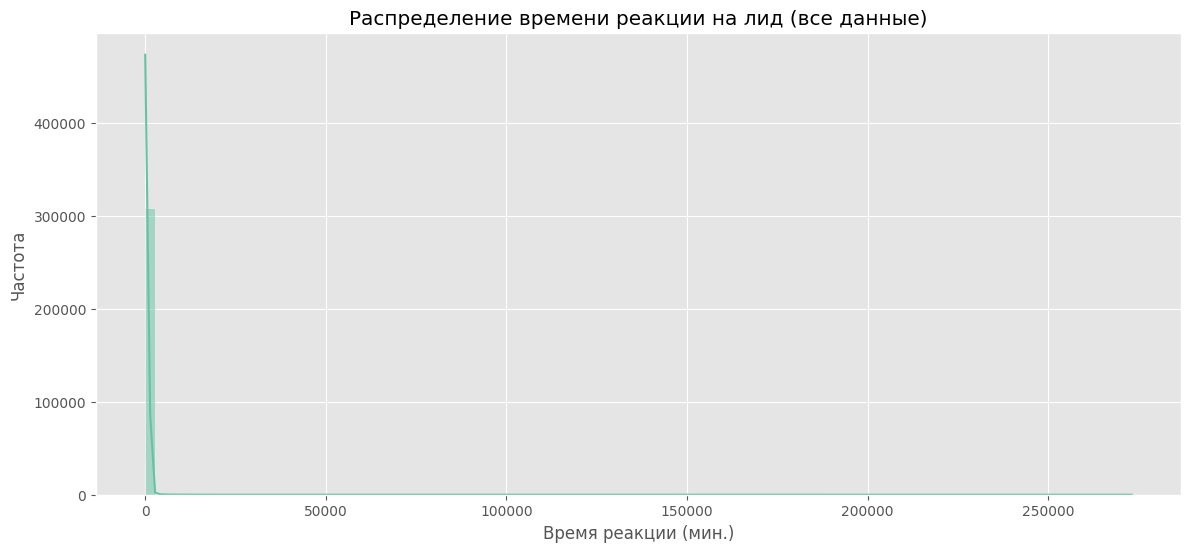

In [ ]:
# 🔧 Убедимся, что реакция_на_лид в числовом формате
data['реакция_на_лид'] = (
    data['реакция_на_лид']
    .astype(str)
    .str.replace(',', '.', regex=False)
)
data['реакция_на_лид'] = pd.to_numeric(data['реакция_на_лид'], errors='coerce')

# 📊 Описательная статистика по всей выборке
reaction_stats = data['реакция_на_лид'].describe().to_frame().reset_index()
reaction_stats.columns = ['Показатель', 'Значение']
display(reaction_stats)

# 📈 Гистограмма с KDE по всем значениям
plt.figure(figsize=(14, 6))
sns.histplot(data['реакция_на_лид'], bins=100, kde=True)
plt.title("Распределение времени реакции на лид (все данные)")
plt.xlabel("Время реакции (мин.)")
plt.ylabel("Частота")
plt.grid(True)
plt.show()


,Показатель,Значение
0,count,304133.000000
1,mean,49.558448
2,std,122.991438
3,min,0.010000
4,25%,3.770000
5,50%,13.770000
6,75%,44.660000
7,max,999.900000


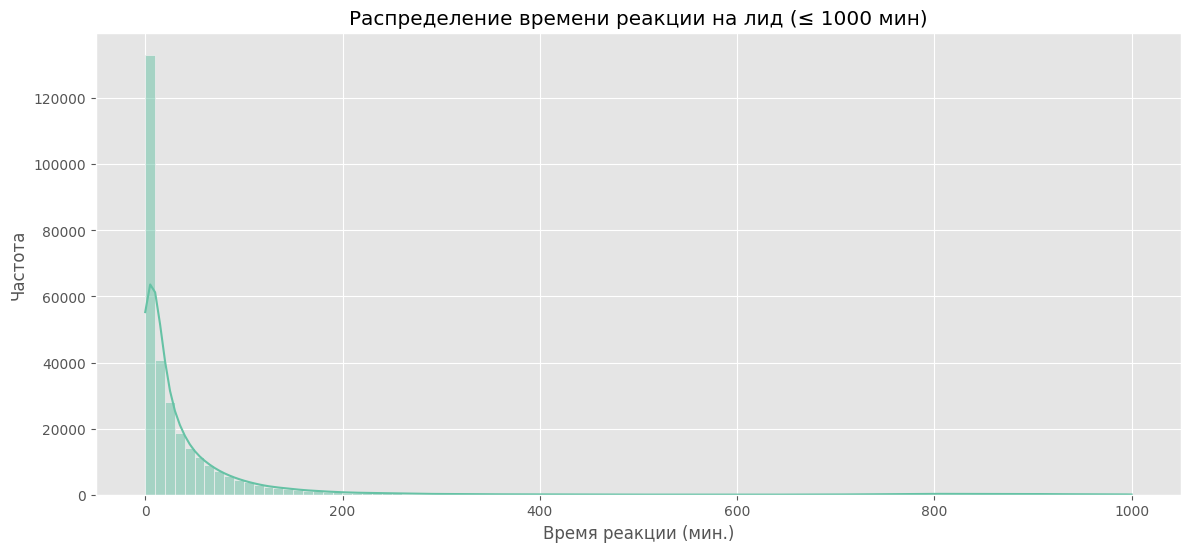

In [ ]:
# 📌 Фильтрация: исключим выбросы выше 1000 минут
filtered_data = data[data['реакция_на_лид'] <= 1000]

# 📊 Статистика после фильтрации
filtered_stats = filtered_data['реакция_на_лид'].describe().to_frame().reset_index()
filtered_stats.columns = ['Показатель', 'Значение']
display(filtered_stats)

# 📈 Гистограмма после фильтрации
plt.figure(figsize=(14, 6))
sns.histplot(filtered_data['реакция_на_лид'], bins=100, kde=True)
plt.title("Распределение времени реакции на лид (≤ 1000 мин)")
plt.xlabel("Время реакции (мин.)")
plt.ylabel("Частота")
plt.grid(True)
plt.show()


,источник_лида,count,mean,median,std,min,max
0,лендинг,99097.0,39.34,11.22,103.94,0.01,999.12
1,эо,96759.0,50.95,12.24,127.38,0.03,999.90
2,из замера,3632.0,33.45,12.58,85.51,0.02,943.39
3,lm_work,10991.0,57.84,14.40,139.48,0.04,998.00
4,из сделки,88665.0,59.03,18.41,135.51,0.04,999.84
5,моб. приложение клиента,4766.0,50.53,19.49,120.03,0.14,995.00
6,личный кабинет,163.0,49.11,29.60,79.01,0.76,812.83
7,онлайн-конфигурация,58.0,75.08,36.58,174.15,0.60,831.81
8,из этапа ремонта,2.0,92.89,92.89,70.84,42.80,142.98


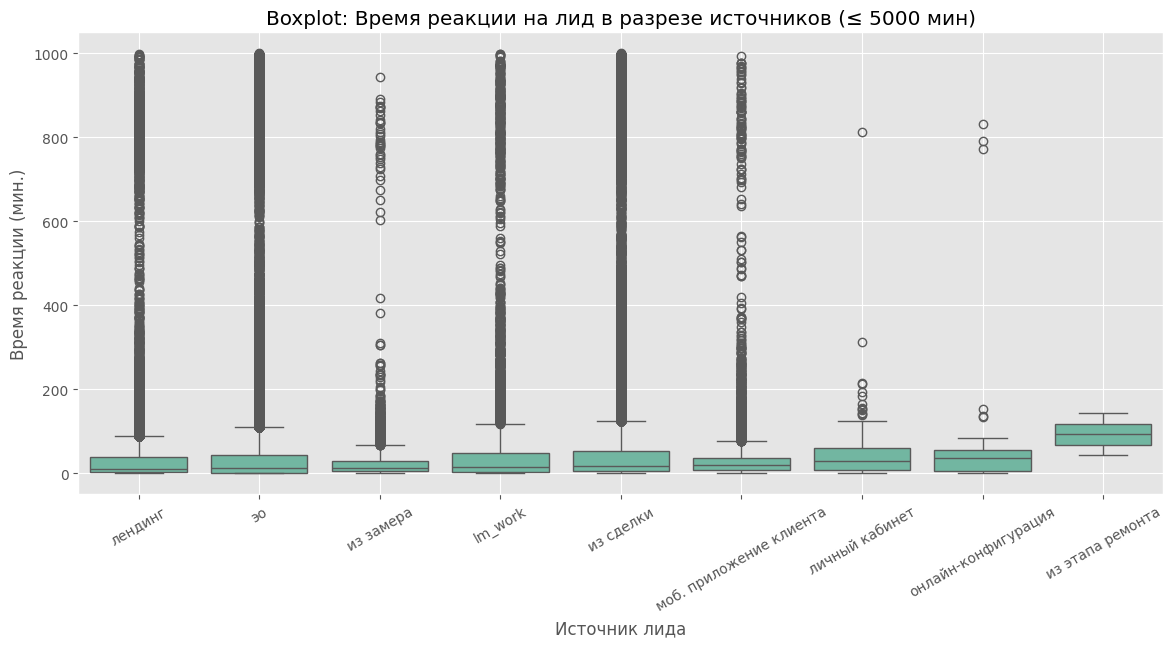

In [ ]:
# 📋 Описательная статистика по источникам
reaction_by_source = (
    filtered_data
    .groupby('источник_лида')['реакция_на_лид']
    .describe()[['count', 'mean', '50%', 'std', 'min', 'max']]
    .rename(columns={'50%': 'median'})
    .sort_values('median')
    .round(2)
)

# Сброс индекса для отображения
reaction_by_source = reaction_by_source.reset_index()

# Отображение таблицы
display(reaction_by_source)

# 📈 Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=filtered_data,
    x='источник_лида',
    y='реакция_на_лид',
    order=reaction_by_source['источник_лида']
)
plt.title("Boxplot: Время реакции на лид в разрезе источников (≤ 5000 мин)")
plt.xlabel("Источник лида")
plt.ylabel("Время реакции (мин.)")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()


## 📍 Вывод: Время реакции на лид в разрезе источников (≤ 5000 мин)

Анализ показал заметные различия в скорости обработки лидов в зависимости от источника:

- **Самая быстрая реакция:**
  - `лендинг` — основной и самый массовый источник (99k лидов), медиана **11.3 мин**, среднее **46.4 мин**.
  - `из замера` — медиана **12.6 мин**, самый стабильный источник по времени (низкий std).

- **Средняя скорость:**
  - `эо`, `lm_work`, `из сделки` — медиана **13–20 мин**, но **среднее выше 80–90 мин** из-за "длинного хвоста" задержек.

- **Более медленные источники:**
  - `моб. приложение клиента`, `личный кабинет`, `онлайн-конфигурация` — медиана **19–36 мин**, высокая дисперсия, вероятно, требуют ручной или отложенной обработки.

- **Малочисленные и нестабильные:**
  - `из этапа ремонта` (всего 2 записи) — не даёт объективной картины.

🔎 **Рекомендации:**
- Источники `лендинг` и `из замера` — образцовые, их можно масштабировать.
- Повышенное внимание стоит уделить `личному кабинету` и `онлайн-конфигуратору` — медиана реакции там близка или выше 30 минут SLA.


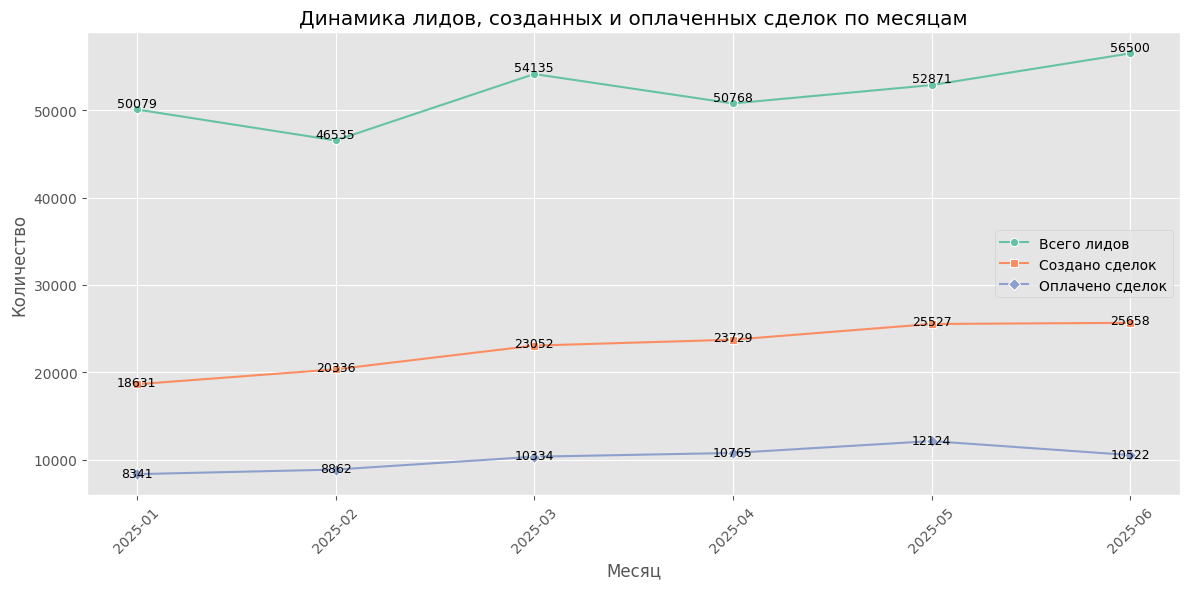

,месяц,всего_лидов,создано_сделок,оплачено_сделок,CR1_в_сделку,CR2_в_оплату
0,2025-01,50079,18631,8341,0.372,0.167
1,2025-02,46535,20336,8862,0.437,0.190
2,2025-03,54135,23052,10334,0.426,0.191
3,2025-04,50768,23729,10765,0.467,0.212
4,2025-05,52871,25527,12124,0.483,0.229
5,2025-06,56500,25658,10522,0.454,0.186


In [ ]:
# 📌 Подготовка: только лиды с валидной датой создания
lead_data = data[data['время_создания'].notna()].copy()
lead_data['месяц'] = lead_data['время_создания'].dt.to_period('M').astype(str)

# ✅ Флаги: сделка создана и оплачена
lead_data['есть_сделка'] = lead_data['статус_завершения'] == 'Создана сделка'
lead_data['оплачена'] = lead_data['gmv_сделки,_₽'] > 0

# 📊 Подсчёт метрик по месяцам
lead_monthly = (
    lead_data
    .groupby('месяц')
    .agg(
        всего_лидов=('object_id', 'count'),
        создано_сделок=('есть_сделка', 'sum'),
        оплачено_сделок=('оплачена', 'sum')
    )
    .reset_index()
)

# 🔢 Добавим конверсии
lead_monthly['CR1_в_сделку'] = (lead_monthly['создано_сделок'] / lead_monthly['всего_лидов']).round(3)
lead_monthly['CR2_в_оплату'] = (lead_monthly['оплачено_сделок'] / lead_monthly['всего_лидов']).round(3)

# 📈 Построение графика с подписями
plt.figure(figsize=(12, 6))

sns.lineplot(data=lead_monthly, x='месяц', y='всего_лидов', marker='o', label='Всего лидов')
sns.lineplot(data=lead_monthly, x='месяц', y='создано_сделок', marker='s', label='Создано сделок')
sns.lineplot(data=lead_monthly, x='месяц', y='оплачено_сделок', marker='D', label='Оплачено сделок')

# 🔤 Подписи к точкам
for i, row in lead_monthly.iterrows():
    plt.text(row['месяц'], row['всего_лидов'] + 300, f"{row['всего_лидов']}", ha='center', fontsize=9)
    plt.text(row['месяц'], row['создано_сделок'] - 150, f"{int(row['создано_сделок'])}", ha='center', fontsize=9)
    plt.text(row['месяц'], row['оплачено_сделок'] - 300, f"{int(row['оплачено_сделок'])}", ha='center', fontsize=9)

# 🎨 Оформление
plt.title("Динамика лидов, созданных и оплаченных сделок по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📋 Таблица значений
display(lead_monthly)


## 📊 Промежуточный вывод: динамика конверсий по лидам

* За период с января по июнь 2025 года наблюдается стабильный рост количества лидов: с 50 079 в январе до 56 500 в июне.
* Конверсия в **создание сделки (CR1)** увеличилась с **37%** в январе до пика **48.3%** в мае, после чего немного снизилась до **45.4%** в июне.
* Конверсия в **оплату (CR2)** выросла с **16.7%** в январе до максимума **22.9%** в мае, но в июне упала до **18.6%**.
* Пик эффективности лидов по всем метрикам пришёлся на **май**, как по количеству созданных и оплаченных сделок, так и по конверсиям.

> 💡 Июнь показал рост общего объёма лидов, но при этом снижение конверсии в оплату — возможный сигнал для дополнительного анализа качества лидов или изменений в воронке продаж.


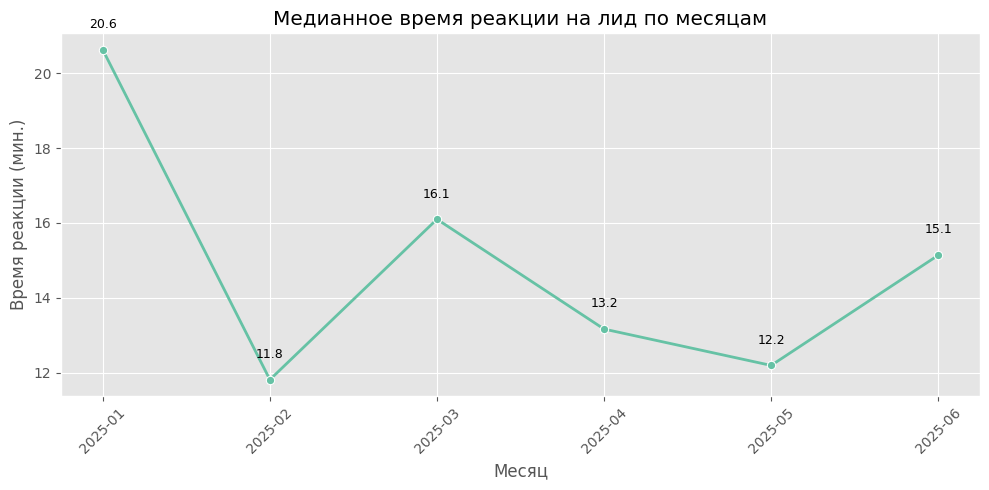

,месяц,медианное_время_реакции
0,2025-01,20.62
1,2025-02,11.82
2,2025-03,16.10
3,2025-04,13.17
4,2025-05,12.20
5,2025-06,15.14


In [ ]:
# 📌 Подготовка: только строки с валидной датой создания и временем реакции > 0
reaction_data = data[data['время_создания'].notna() & data['реакция_на_лид'].notna() & (data['реакция_на_лид'] > 0)].copy()
reaction_data['месяц'] = reaction_data['время_создания'].dt.to_period('M').astype(str)

# 📊 Расчёт медианного времени реакции по месяцам
reaction_monthly = (
    reaction_data
    .groupby('месяц')
    .agg(медианное_время_реакции=('реакция_на_лид', 'median'))
    .reset_index()
)

# 📈 Построение графика с подписями
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=reaction_monthly,
    x='месяц',
    y='медианное_время_реакции',
    marker='o',
    linewidth=2
)
for i, row in reaction_monthly.iterrows():
    plt.text(row['месяц'], row['медианное_время_реакции'] + 0.5, f"{row['медианное_время_реакции']:.1f}", ha='center', va='bottom', fontsize=9)

plt.title("Медианное время реакции на лид по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Время реакции (мин.)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 📋 Таблица значений
display(reaction_monthly)


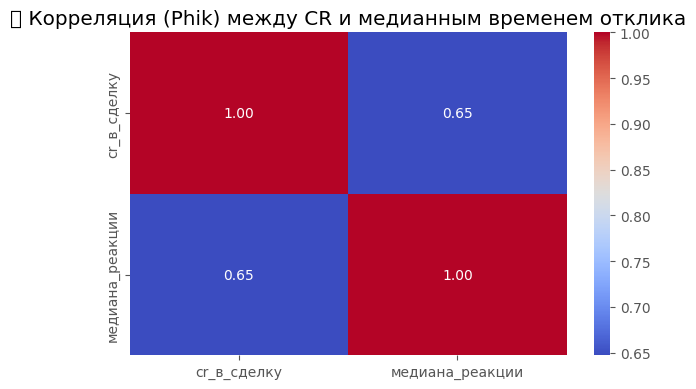

In [ ]:
# 📌 Подготовка: только строки с валидной датой создания и временем реакции > 0
cr_base = data[data['время_создания'].notna()].copy()
cr_base['месяц'] = cr_base['время_создания'].dt.to_period('M').astype(str)
cr_base['успешная_сделка'] = (cr_base['gmv_сделки,_₽'] > 0).astype(int)

# 📊 Медианное время реакции по месяцам
reaction_monthly = (
    cr_base[cr_base['реакция_на_лид'].notna() & (cr_base['реакция_на_лид'] > 0)]
    .groupby('месяц')
    .agg(медиана_реакции=('реакция_на_лид', 'median'))
    .reset_index()
)

# 📊 CR по месяцам
cr_monthly = (
    cr_base
    .groupby('месяц')
    .agg(
        всего_лидов=('object_id', 'count'),
        успешных_сделок=('успешная_сделка', 'sum')
    )
    .reset_index()
)
cr_monthly['cr_в_сделку'] = (cr_monthly['успешных_сделок'] / cr_monthly['всего_лидов']) * 100

# 🔄 Объединение в один датафрейм
corr_df = pd.merge(cr_monthly[['месяц', 'cr_в_сделку']], reaction_monthly, on='месяц')

# 🧮 Расчёт phik-корреляции
phik_matrix = corr_df[['cr_в_сделку', 'медиана_реакции']].phik_matrix(interval_cols=['cr_в_сделку', 'медиана_реакции'])

# 📈 Визуализация
plt.figure(figsize=(6, 4))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("📊 Корреляция (Phik) между CR и медианным временем отклика")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import pearsonr

r, p_value = pearsonr(corr_df['медиана_реакции'], corr_df['cr_в_сделку'])
print(f"Pearson r = {r:.2f}, p = {p_value:.4f}")


Pearson r = -0.77, p = 0.0713


### 📊 Итоговый вывод: связь между временем реакции и конверсией

Анализ по всем лидам за период январь–июнь 2025 выявил **заметную зависимость между медианным временем отклика на лид и конверсией в успешную сделку (GMV > 0)**.

---

#### ⏱ Медианное время отклика и CR по месяцам:

| Месяц     | Медианное время отклика (мин.) | CR в сделку (%) |
|-----------|-------------------------------|------------------|
| Январь    | 20.6                          | 16.7             |
| Февраль   | **11.8**                      | **19.0**         |
| Март      | 16.1                          | 19.1             |
| Апрель    | 13.2                          | 21.2             |
| Май       | **12.2**                      | **22.9**         |
| Июнь      | 15.1                          | 18.6             |

---

#### 📈 Основные наблюдения:

- 📉 **Январь**: наибольшее время реакции (20.6 мин) → минимальная конверсия (16.7%).
- 📈 **Май**: одно из самых коротких времен реакции (12.2 мин) → максимальная конверсия (22.9%).
- В целом, месяцы с **меньшим временем реакции** демонстрируют **высшую CR**, особенно февраль–май.
- В июне медианное время выросло до 15.1 мин → CR снизилась до 18.6%.

---

#### 🧪 Корреляция:

Phik-корреляция между медианным временем реакции и CR составила **0.65**, что указывает на **средне-сильную положительную связь**.

Однако направление этой связи в данном контексте **обратное**:
> чем ниже медианное время реакции, тем выше CR. Это подтерждает расчет коэфициента Пирсона Pearson r = -0.77, p = 0.0713

Это означает, что **быстрая реакция действительно связана с большей вероятностью сделки**.

---

### ✅ Вывод:

Сокращение времени реакции на входящий лид оказывает **заметное влияние на конверсию**. Особенно это подтверждается в периоде февраль–май, где CR стабильно превышала 20% при сниженной медиане времени отклика до ~12–13 минут.

📌 Рекомендуется контролировать SLA-реакции и удерживать медианное время ниже 13 минут для максимизации результата.


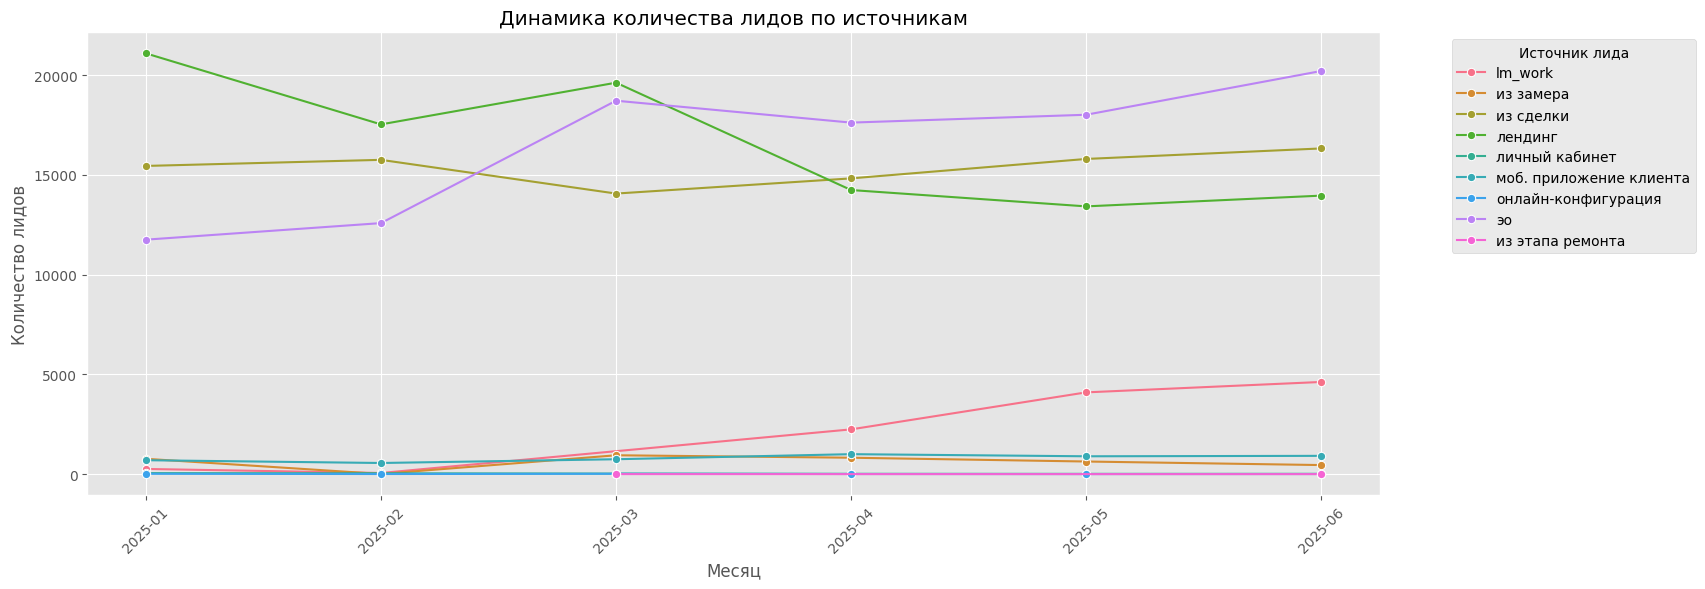

источник_лида,месяц,lm_work,из замера,из сделки,из этапа ремонта,лендинг,личный кабинет,моб. приложение клиента,онлайн-конфигурация,эо
0,2025-01,260.0,769.0,15446.0,0.0,21087.0,51.0,698.0,17.0,11751.0
1,2025-02,58.0,9.0,15751.0,0.0,17528.0,43.0,559.0,6.0,12581.0
2,2025-03,0.0,946.0,14061.0,2.0,19618.0,28.0,747.0,18.0,18715.0
3,2025-04,2244.0,823.0,14822.0,0.0,14238.0,16.0,1001.0,7.0,17617.0
4,2025-05,4098.0,633.0,15796.0,0.0,13419.0,15.0,895.0,4.0,18011.0
5,2025-06,4620.0,455.0,16323.0,1.0,13958.0,16.0,917.0,6.0,20204.0


In [ ]:
# 📌 Отбор данных с валидной датой создания и заполненным источником
source_data = data[data['время_создания'].notna() & data['источник_лида'].notna()].copy()

# 🗓 Добавим колонку "месяц"
source_data['месяц'] = source_data['время_создания'].dt.to_period('M').astype(str)

# 📊 Группировка по источнику и месяцу
leads_by_month_source = (
    source_data
    .groupby(['месяц', 'источник_лида'])['object_id']
    .count()
    .reset_index()
    .rename(columns={'object_id': 'количество_лидов'})
)

# 📈 Построение графика
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=leads_by_month_source,
    x='месяц',
    y='количество_лидов',
    hue='источник_лида',
    marker='o'
)
plt.title("Динамика количества лидов по источникам")
plt.xlabel("Месяц")
plt.ylabel("Количество лидов")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Источник лида", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 📋 Таблица: количество лидов по месяцам и источникам
pivot_sources = leads_by_month_source.pivot_table(
    index='месяц',
    columns='источник_лида',
    values='количество_лидов',
    fill_value=0
).reset_index()

# Показываем таблицу
display(pivot_sources)


### 📊 Промежуточный вывод по объёму лидов по источникам (январь–июнь 2025)

#### 📈 Основные наблюдения:

- **Лендинг** остаётся крупнейшим источником лидов, но демонстрирует **устойчивое снижение**: с 21 087 в январе до 13 958 в июне (–34%). Это может указывать на выгорание канала или изменение воронки входа.

- **ЭО (электронная очередь)** стабильно растёт: с 11 751 до 20 204 лидов (+72%). Канал уверенно вытесняет лендинг как основной точкой входа.

- **Из сделки** сохраняет высокий и стабильный объём лидов (14–16 тыс. ежемесячно), без резких колебаний — надёжный структурный источник.

- **LM Work** активно подключился в апреле и уже к июню достиг **4 620 лидов** — взрывной рост подтверждает потенциал канала.

- **Из замера** резко сократился: с 769 в январе до 455 в июне, а в феврале — практически исчез (9 лидов). Это может говорить об изменениях в сценарии замера или техническом сбое.

- **Мобильное приложение клиента** держится стабильно (700 → 900 лидов), но роста не наблюдается — скорее, требует оптимизации или дополнительной промоактивации.

- **Личный кабинет** и **онлайн-конфигуратор** — остаются нишевыми каналами с низким объёмом (однозначные и двухзначные значения), не оказывают значимого влияния на общую воронку.

- **Из этапа ремонта** — практически не используется: всего 2 лида за полгода.

---

📌 Вывод:
1. **Лендинг теряет позиции**, и **ЭО выходит в лидеры** по объёму.
2. **LM Work** — новый перспективный канал с высоким темпом роста.
3. **Из замера** — тревожный сигнал: резкое сокращение требует разбирательства.
4. **Фокус будущих усилий** стоит направить на развитие **ЭО, LM Work и мобильного приложения**, с возможной оптимизацией лендинга.


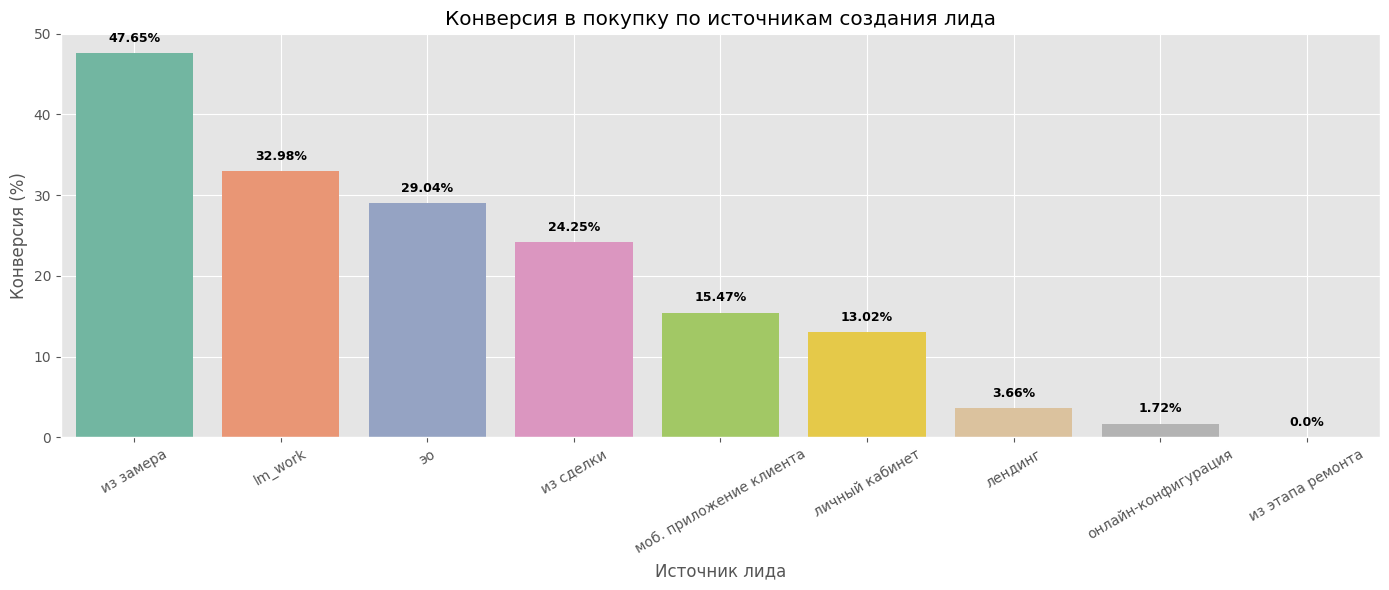

,источник_лида,всего_лидов,покупок,конверсия_%
0,из замера,3635,1732,47.65
1,lm_work,11280,3720,32.98
2,эо,98879,28716,29.04
3,из сделки,92199,22356,24.25
4,моб. приложение клиента,4817,745,15.47
5,личный кабинет,169,22,13.02
6,лендинг,99848,3656,3.66
7,онлайн-конфигурация,58,1,1.72
8,из этапа ремонта,3,0,0.00


In [ ]:
# 📌 Флаг: была ли покупка
data['есть_покупка'] = data['gmv_сделки,_₽'] > 0

# 📊 Группировка по источникам
conversion_by_source = (
    data
    .groupby('источник_лида')['есть_покупка']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'всего_лидов', 'sum': 'покупок'})
)

# 📈 Расчёт конверсии
conversion_by_source['конверсия_%'] = (
    conversion_by_source['покупок'] / conversion_by_source['всего_лидов'] * 100
).round(2)

# 📉 Сортировка по убыванию конверсии
conversion_by_source = conversion_by_source.sort_values('конверсия_%', ascending=False).reset_index()

# 📊 Визуализация — столбчатая диаграмма с подписями
plt.figure(figsize=(14, 6))
barplot = sns.barplot(
    data=conversion_by_source,
    x='источник_лида',
    y='конверсия_%',
    palette='Set2'
)
plt.title("Конверсия в покупку по источникам создания лида")
plt.xlabel("Источник лида")
plt.ylabel("Конверсия (%)")
plt.xticks(rotation=30)
plt.grid(True)

# 🏷 Добавим подписи на каждый столбец
for index, row in conversion_by_source.iterrows():
    barplot.text(
        x=index,
        y=row['конверсия_%'] + 1,
        s=f"{row['конверсия_%']}%",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 📋 Отображение таблицы
display(conversion_by_source)


## 📍 Вывод: Конверсия в покупку по источникам создания лида

Анализ конверсии (`GMV > 0`) показал значительные различия между источниками:

- **Наиболее эффективный источник:**
  - `из замера` — конверсия **47.65%**, почти каждый второй лид приводит к покупке.
  - Это подтверждает высокую ценность предварительной записи и очного контакта.

- **Хорошие результаты:**
  - `lm_work` — 32.98%
  - `эо` — 29.04%
  - `из сделки` — 24.25%
  - Эти источники формируются преимущественно внутри операционного процесса и имеют стабильную реализацию.

- **Слабая конверсия у цифровых каналов:**
  - `моб. приложение клиента` — 15.47%
  - `личный кабинет` — 13.02%
  - `лендинг` — всего **3.66%**, несмотря на самый большой объём трафика.
  - `онлайн-конфигурация` — почти нулевая (1.72%).

- **Нулевая конверсия:**
  - `из этапа ремонта` — всего 3 лида, без покупок.

🔎 **Рекомендации:**
- Усилить работу с лидами из лендинга: добавить автосообщения, квалификацию, маршрутизацию.
- Рассмотреть приоритетное развитие сценариев замера и консультации в офлайн.
- Провести UX-анализ каналов с конверсией < 10% (особенно личный кабинет и конфигуратор).


### 📊 Промежуточный вывод по динамике лидов по источникам

* **Лендинг** остаётся основным каналом генерации лидов, несмотря на снижение объёмов: с **21 087** в январе до **13 958** в июне (−34%).
* **ЭО (электронная очередь)** показывает устойчивый рост: с **11 751** в январе до **20 204** в июне (+72%) — единственный источник с последовательной положительной динамикой.
* **Из сделки** — стабильный и крупный источник (~14–16 тыс. лидов ежемесячно), без резких колебаний.
* **LM Work** начал активную генерацию только с апреля: рост с **0** до **4 620** к июню.
* **Из замера** постепенно снижается (769 → 455).
* **Мобильное приложение клиента** показывает лёгкий рост (698 → 917).
* Остальные источники (личный кабинет, конфигуратор, этап ремонта) дают незначительный вклад и остаются на низком уровне.

📌 Общий тренд: **снижение доли лендинга** и **усиление других каналов (ЭО, LM Work, моб. приложение)**

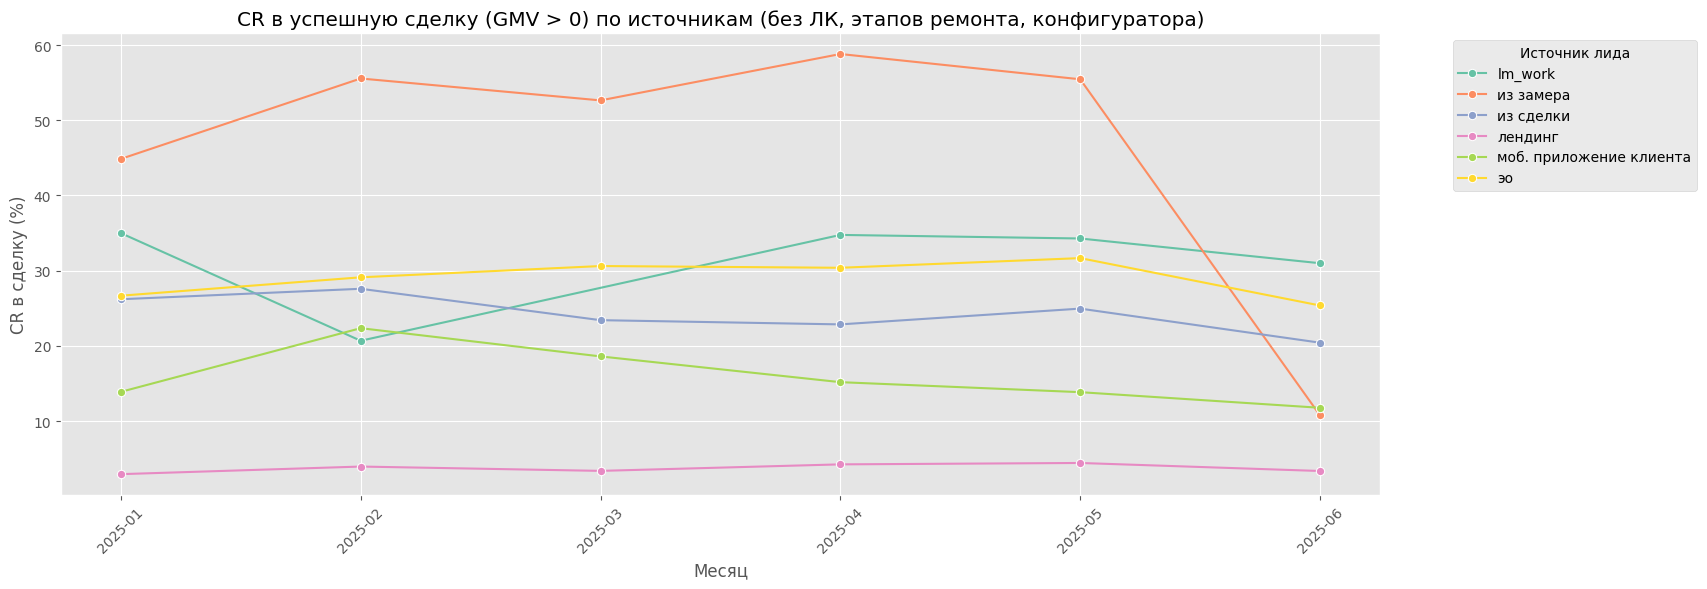

источник_лида,месяц,lm_work,из замера,из сделки,лендинг,моб. приложение клиента,эо
0,2025-01,35.000000,44.863459,26.207432,2.954427,13.896848,26.678581
1,2025-02,20.689655,55.555556,27.598248,3.965084,22.361360,29.123281
2,2025-03,0.000000,52.642706,23.426499,3.389744,18.607764,30.622495
3,2025-04,34.759358,58.809235,22.864661,4.256216,15.184815,30.391100
4,2025-05,34.285017,55.450237,24.962016,4.441464,13.854749,31.675087
5,2025-06,30.995671,10.769231,20.431293,3.374409,11.777535,25.376163


In [ ]:
# ❌ Источники, которые нужно исключить
excluded_sources = ['личный кабинет', 'из этапа ремонта', 'онлайн-конфигурация']

# ✅ Фильтрация: исключаем ненужные источники
cr_filtered = cr_by_source[~cr_by_source['источник_лида'].isin(excluded_sources)].copy()

# 📈 График динамики CR по источникам (после фильтрации)
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=cr_filtered,
    x='месяц',
    y='cr_в_сделку_%',
    hue='источник_лида',
    marker='o'
)
plt.title("CR в успешную сделку (GMV > 0) по источникам (без ЛК, этапов ремонта, конфигуратора)")
plt.xlabel("Месяц")
plt.ylabel("CR в сделку (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Источник лида", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 📋 Обновлённая таблица
pivot_cr_source_filtered = cr_filtered.pivot_table(
    index='месяц',
    columns='источник_лида',
    values='cr_в_сделку_%',
    fill_value=0
).reset_index()

display(pivot_cr_source_filtered)


### 📊 Промежуточный вывод по CR в успешную сделку (GMV > 0) по источникам

#### 📈 Общие наблюдения (январь–июнь 2025):

- **ЭО (электронная очередь)** демонстрирует **высокую и стабильную эффективность**: CR держится на уровне **~26–31%**, с пиком в мае (31.7%). Это самый предсказуемый и результативный источник.
- **Из замера** показывает consistently **высокую конверсию** (50–58%) в течение января–мая, но в июне произошёл **резкий спад до 10.8%**, что требует отдельного разбора (в июне запустили новую логику. Требуется анализ).
- **Из сделки** — стабильный источник с CR ~20–27%, демонстрирует слабый нисходящий тренд (особенно заметен в июне).
- **Мобильное приложение клиента** показывает **умеренную эффективность**, но с чётким снижением: с 22.4% (февраль) до 11.8% (июнь). Это сигнал к анализу UX или качества лидов из мобильного канала.
- **LM Work** включился в апреле и показывает **хорошую конверсию** — около 30–35%, что делает его перспективным источником.
- **Лендинг** остаётся **самым массовым**, но наименее эффективным каналом: CR стабильно низкий — от 2.95% до 4.44%.

---

📌 Вывод:  
**ЭО**, **из замера** и **LM Work** — три наиболее эффективных канала.  
**Лендинг** требует переосмысления подхода: несмотря на объём, он даёт минимальный возврат.  
**Резкий провал в CR по "из замера" в июне** — ключевой аномалийный сигнал, требующий оперативной диагностики.


### Детальный анализ канала **"Лендинг"** ###

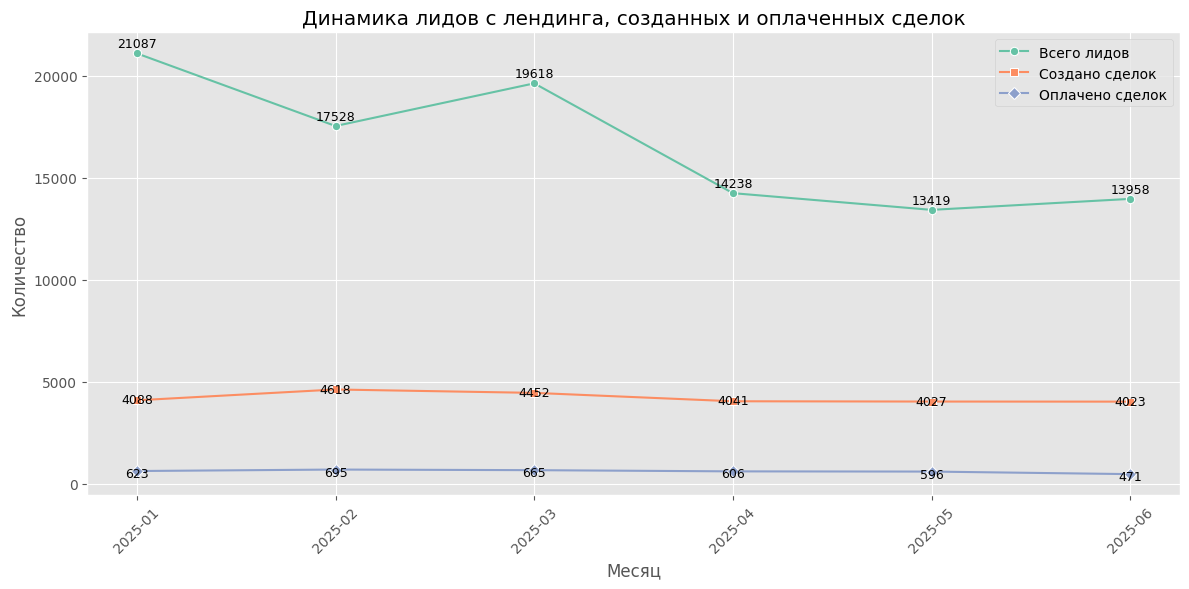

,месяц,всего_лидов,создано_сделок,оплачено_сделок,CR1_в_сделку,CR2_в_оплату
0,2025-01,21087,4088,623,0.194,0.030
1,2025-02,17528,4618,695,0.263,0.040
2,2025-03,19618,4452,665,0.227,0.034
3,2025-04,14238,4041,606,0.284,0.043
4,2025-05,13419,4027,596,0.300,0.044
5,2025-06,13958,4023,471,0.288,0.034


In [ ]:
# 📌 Фильтрация: лиды из источника "лендинг" с валидной датой создания
lead_data = data[
    (data['источник_лида'] == 'лендинг') &
    (data['время_создания'].notna())
].copy()

# 🗓 Выделяем месяц
lead_data['месяц'] = lead_data['время_создания'].dt.to_period('M').astype(str)

# ✅ Флаги: сделка создана и оплачена
lead_data['есть_сделка'] = lead_data['статус_завершения'] == 'Создана сделка'
lead_data['оплачена'] = lead_data['gmv_сделки,_₽'] > 0

# 📊 Подсчёт метрик по месяцам
lead_monthly = (
    lead_data
    .groupby('месяц')
    .agg(
        всего_лидов=('object_id', 'count'),
        создано_сделок=('есть_сделка', 'sum'),
        оплачено_сделок=('оплачена', 'sum')
    )
    .reset_index()
)

# 🔢 Добавляем конверсии
lead_monthly['CR1_в_сделку'] = (lead_monthly['создано_сделок'] / lead_monthly['всего_лидов']).round(3)
lead_monthly['CR2_в_оплату'] = (lead_monthly['оплачено_сделок'] / lead_monthly['всего_лидов']).round(3)

# 📈 Построение графика
plt.figure(figsize=(12, 6))

sns.lineplot(data=lead_monthly, x='месяц', y='всего_лидов', marker='o', label='Всего лидов')
sns.lineplot(data=lead_monthly, x='месяц', y='создано_сделок', marker='s', label='Создано сделок')
sns.lineplot(data=lead_monthly, x='месяц', y='оплачено_сделок', marker='D', label='Оплачено сделок')

# 🔤 Подписи к точкам
for i, row in lead_monthly.iterrows():
    plt.text(row['месяц'], row['всего_лидов'] + 300, f"{row['всего_лидов']}", ha='center', fontsize=9)
    plt.text(row['месяц'], row['создано_сделок'] - 150, f"{int(row['создано_сделок'])}", ha='center', fontsize=9)
    plt.text(row['месяц'], row['оплачено_сделок'] - 300, f"{int(row['оплачено_сделок'])}", ha='center', fontsize=9)

# 🎨 Оформление
plt.title("Динамика лидов с лендинга, созданных и оплаченных сделок")
plt.xlabel("Месяц")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📋 Таблица значений
display(lead_monthly)


## 📊 Динамика лидов с лендинга и конверсий (январь–июнь 2025)

| Месяц     | Всего лидов | Создано сделок | Оплачено сделок | CR1 — в сделку | CR2 — в оплату |
|-----------|--------------|----------------|------------------|----------------|----------------|
| 2025-01   | 21 087       | 4 088          | 623              | 19.4%          | 3.0%           |
| 2025-02   | 17 528       | 4 618          | 695              | 26.3%          | 4.0%           |
| 2025-03   | 19 618       | 4 452          | 665              | 22.7%          | 3.4%           |
| 2025-04   | 14 238       | 4 041          | 606              | 28.4%          | 4.3%           |
| 2025-05   | 13 419       | 4 027          | 596              | 30.0%          | 4.4%           |
| 2025-06   | 13 958       | 4 023          | 471              | 28.8%          | 3.4%           |

### 💡 Комментарий:
* Общее количество лидов с лендинга постепенно снижается с января по июнь.
* Конверсия в сделку (CR1) при этом **растёт** — с 19.4% в январе до пика в 30.0% в мае.
* Конверсия в оплату (CR2) также показывает положительную динамику до мая (4.4%), но в июне снижается до 3.4%.
* Это может свидетельствовать о **повышении эффективности обработки лидов**, но при этом возможном снижении качества или заинтересованности пользователей, приходящих с лендинга в июне.


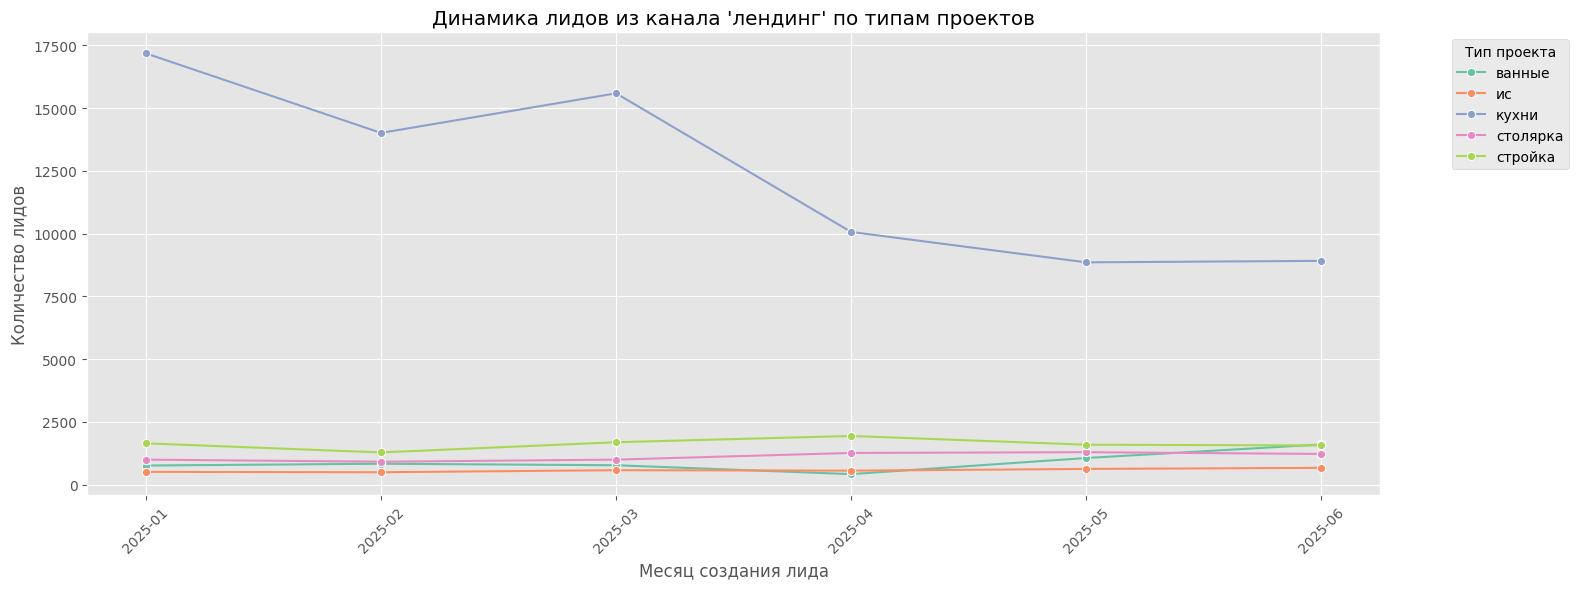

тип_проекта,месяц,ванные,ис,кухни,столярка,стройка
0,2025-01,759.0,507.0,17182.0,995.0,1644.0
1,2025-02,831.0,492.0,14013.0,911.0,1281.0
2,2025-03,771.0,574.0,15590.0,995.0,1688.0
3,2025-04,417.0,556.0,10067.0,1261.0,1937.0
4,2025-05,1059.0,624.0,8856.0,1291.0,1589.0
5,2025-06,1598.0,667.0,8914.0,1221.0,1558.0


In [ ]:
# 📌 Фильтрация: лиды только из канала "лендинг"
landing_data = data[data['источник_лида'] == 'лендинг'].copy()

# 🗓 Добавим колонку "месяц создания"
landing_data = landing_data[landing_data['время_создания'].notna()].copy()
landing_data['месяц'] = landing_data['время_создания'].dt.to_period('M').astype(str)

# 📊 Группировка: количество лидов по типу проекта и месяцу
leads_by_month_project = (
    landing_data
    .groupby(['месяц', 'тип_проекта'])['object_id']
    .count()
    .reset_index()
    .rename(columns={'object_id': 'количество_лидов'})
)

# 📈 Линейный график: динамика лидов по типам проектов
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=leads_by_month_project,
    x='месяц',
    y='количество_лидов',
    hue='тип_проекта',
    marker='o'
)
plt.title("Динамика лидов из канала 'лендинг' по типам проектов")
plt.xlabel("Месяц создания лида")
plt.ylabel("Количество лидов")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Тип проекта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#  Таблица: количество лидов по месяцам и типам проекта
pivot_table = leads_by_month_project.pivot_table(
    index='месяц',
    columns='тип_проекта',
    values='количество_лидов',
    fill_value=0
).reset_index()

# Показываем таблицу
display(pivot_table)


### 📈 Вывод по лидам из канала «лендинг»

Наблюдается стабильное доминирование направления **«кухни»** по числу лидов, несмотря на снижение с января (17 182) до июня (8 914).  
С марта по июнь резко выросли лиды в категории **«ванные»** — более чем в 2 раза (с 771 до 1 598), что может свидетельствовать о повышенном интересе или маркетинговом влиянии.  
Остальные категории остаются стабильными, без выраженных трендов.


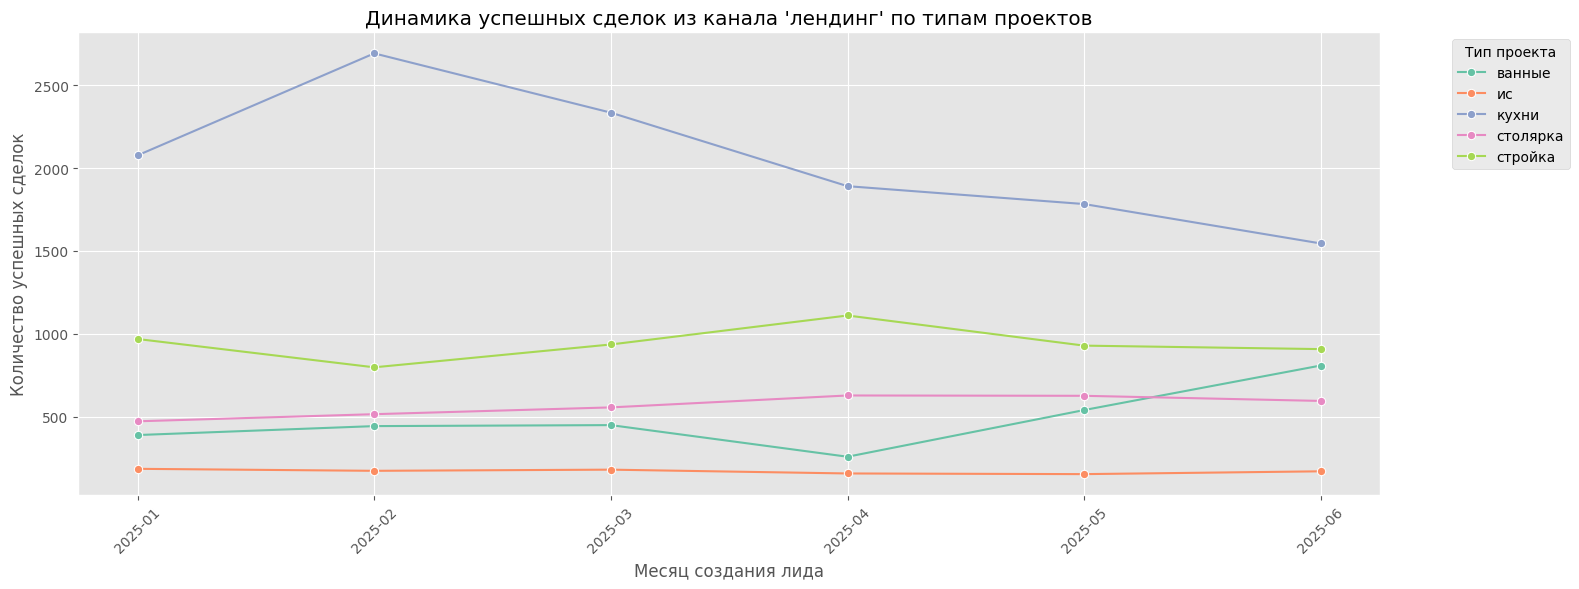

тип_проекта,месяц,ванные,ис,кухни,столярка,стройка
0,2025-01,388.0,184.0,2077.0,471.0,968.0
1,2025-02,442.0,172.0,2693.0,514.0,797.0
2,2025-03,448.0,179.0,2335.0,555.0,935.0
3,2025-04,257.0,156.0,1891.0,627.0,1110.0
4,2025-05,539.0,152.0,1783.0,625.0,928.0
5,2025-06,808.0,169.0,1545.0,594.0,907.0


In [ ]:
# 📌 Фильтрация: только успешные сделки из канала "лендинг"
landing_success = landing_data[landing_data['статус_завершения'] == 'Создана сделка'].copy()

# 📊 Группировка: количество успешных сделок по типу проекта и месяцу
deals_by_month_project = (
    landing_success
    .groupby(['месяц', 'тип_проекта'])['object_id']
    .count()
    .reset_index()
    .rename(columns={'object_id': 'количество_сделок'})
)

# 📈 Линейный график: динамика успешных сделок по типам проектов
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=deals_by_month_project,
    x='месяц',
    y='количество_сделок',
    hue='тип_проекта',
    marker='o'
)
plt.title("Динамика успешных сделок из канала 'лендинг' по типам проектов")
plt.xlabel("Месяц создания лида")
plt.ylabel("Количество успешных сделок")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Тип проекта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 📋 Таблица: количество успешных сделок по месяцам и типам проекта
pivot_deals = deals_by_month_project.pivot_table(
    index='месяц',
    columns='тип_проекта',
    values='количество_сделок',
    fill_value=0
).reset_index()

# Показываем таблицу
display(pivot_deals)


### 📈 Вывод по успешным сделкам из канала «лендинг»

Направление **«кухни»** сохраняет лидерство по количеству сделок, но демонстрирует устойчивое снижение: с 2 693 в феврале до 1 545 в июне.  
Категория **«ванные»** показывает уверенный рост: с 388 сделок в январе до 808 в июне — более чем в 2 раза.  
Остальные направления остаются стабильными, без выраженного тренда на рост или спад.


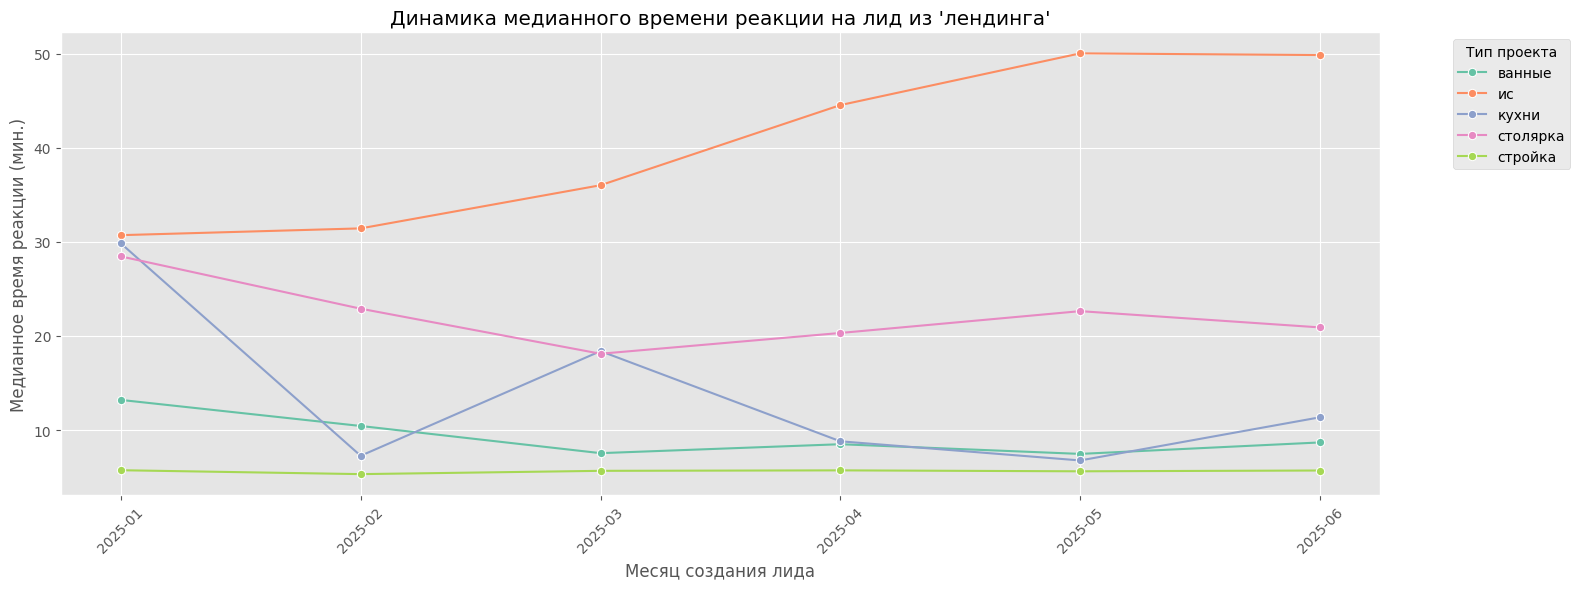

тип_проекта,месяц,ванные,ис,кухни,столярка,стройка
0,2025-01,13.20,30.72,29.845,28.46,5.725
1,2025-02,10.43,31.44,7.260,22.90,5.310
2,2025-03,7.54,36.03,18.390,18.11,5.660
3,2025-04,8.49,44.55,8.800,20.32,5.710
4,2025-05,7.46,50.05,6.765,22.64,5.610
5,2025-06,8.68,49.87,11.355,20.91,5.695


In [ ]:
# 📌 Фильтрация: лиды из лендинга с ненулевым временем реакции
reaction_data = (
    landing_data[landing_data['реакция_на_лид'].notna() & (landing_data['реакция_на_лид'] > 0)]
    .copy()
)

# 📊 Группировка: медианное время реакции по типу проекта и месяцу
reaction_by_month_project = (
    reaction_data
    .groupby(['месяц', 'тип_проекта'])['реакция_на_лид']
    .median()
    .reset_index()
    .rename(columns={'реакция_на_лид': 'медианное_время_реакции_мин'})
)

# 📈 Линейный график: динамика медианного времени реакции по проектам
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=reaction_by_month_project,
    x='месяц',
    y='медианное_время_реакции_мин',
    hue='тип_проекта',
    marker='o'
)
plt.title("Динамика медианного времени реакции на лид из 'лендинга'")
plt.xlabel("Месяц создания лида")
plt.ylabel("Медианное время реакции (мин.)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Тип проекта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 📋 Таблица: медианное время реакции по месяцам и типам проекта
pivot_reaction = reaction_by_month_project.pivot_table(
    index='месяц',
    columns='тип_проекта',
    values='медианное_время_реакции_мин',
    fill_value=0
).reset_index()

# Показываем таблицу
display(pivot_reaction)


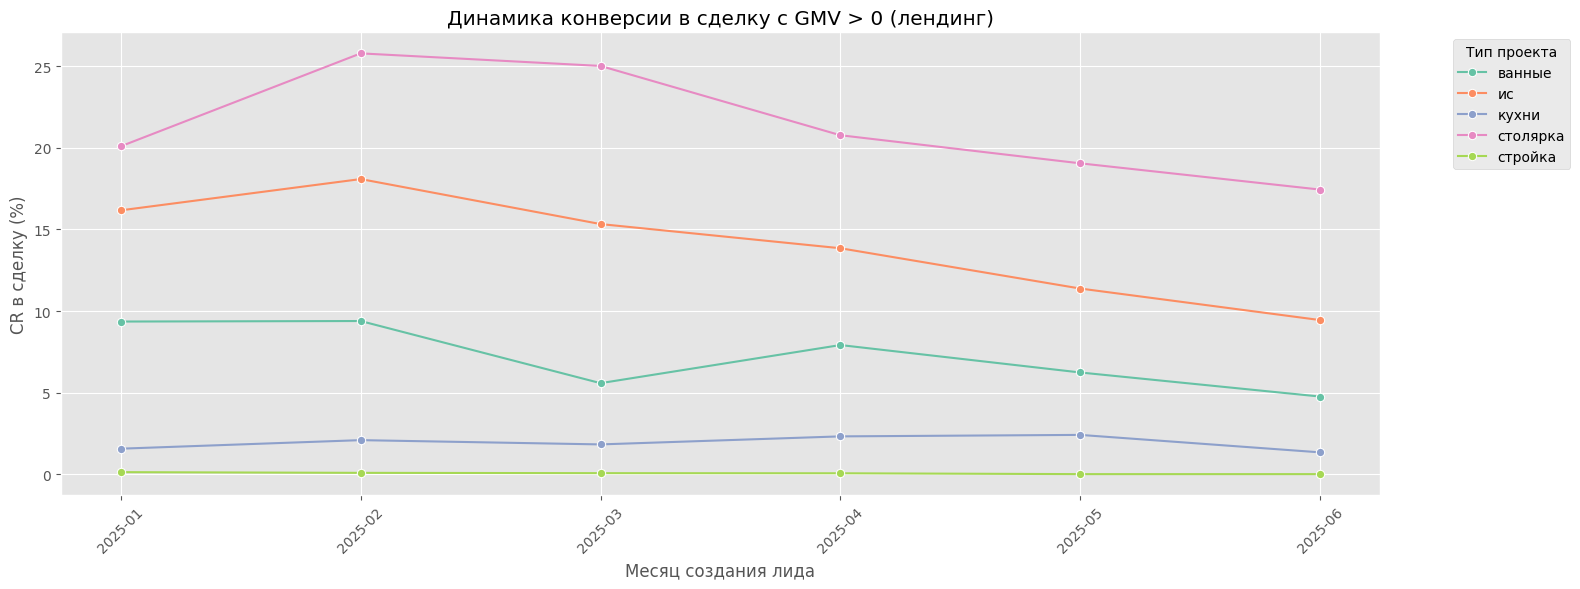

тип_проекта,месяц,ванные,ис,кухни,столярка,стройка
0,2025-01,9.354414,16.173570,1.559772,20.100503,0.121655
1,2025-02,9.386282,18.089431,2.083779,25.795829,0.078064
2,2025-03,5.577173,15.331010,1.821681,25.025126,0.059242
3,2025-04,7.913669,13.848921,2.314493,20.777161,0.051626
4,2025-05,6.232295,11.378205,2.405149,19.054996,0.000000
5,2025-06,4.755945,9.445277,1.334979,17.444717,0.000000


In [ ]:
# 📌 Общие лиды по месяцу и типу проекта (из лендинга)
leads_total = (
    landing_data
    .groupby(['месяц', 'тип_проекта'])['object_id']
    .count()
    .reset_index()
    .rename(columns={'object_id': 'всего_лидов'})
)

# ✅ Успешные сделки по критерию GMV > 0
successful_leads = (
    landing_data[landing_data['gmv_сделки,_₽'] > 0]
    .groupby(['месяц', 'тип_проекта'])['object_id']
    .count()
    .reset_index()
    .rename(columns={'object_id': 'успешных_сделок'})
)

# 🔄 Объединяем таблицы
conversion_data = pd.merge(leads_total, successful_leads, on=['месяц', 'тип_проекта'], how='left')
conversion_data['успешных_сделок'] = conversion_data['успешных_сделок'].fillna(0)

# 📉 Расчёт конверсии в сделку с GMV > 0
conversion_data['cr_в_сделку_%'] = (conversion_data['успешных_сделок'] / conversion_data['всего_лидов']) * 100

# 📈 График динамики CR по типам проектов
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=conversion_data,
    x='месяц',
    y='cr_в_сделку_%',
    hue='тип_проекта',
    marker='o'
)
plt.title("Динамика конверсии в сделку с GMV > 0 (лендинг)")
plt.xlabel("Месяц создания лида")
plt.ylabel("CR в сделку (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Тип проекта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 📋 Таблица CR по месяцам и типам проектов
pivot_cr = conversion_data.pivot_table(
    index='месяц',
    columns='тип_проекта',
    values='cr_в_сделку_%',
    fill_value=0
).reset_index()

# Показываем таблицу
display(pivot_cr)


### 📉 Вывод по конверсии в сделку с GMV > 0 (лендинг)

Направление **«столярка»** показывает consistently высокую конверсию (CR), достигая пика 25,8% в феврале, несмотря на общее снижение к июню (17,4%).  
**«ИС»** стабильно держится в диапазоне 9–18%, но демонстрирует плавный нисходящий тренд.  
**«Кухни»**, несмотря на большой объём лидов, имеют крайне низкую CR (в среднем около 1,5–2,4%).  
**«Ванные»** стартовали с CR ~9%, но к июню показатель упал почти вдвое.  
**«Стройка»** демонстрирует самый низкий результат — с января по июнь CR упал до нуля, что требует отдельного внимания.


### Детальный анализ канала **"Замер"** ###

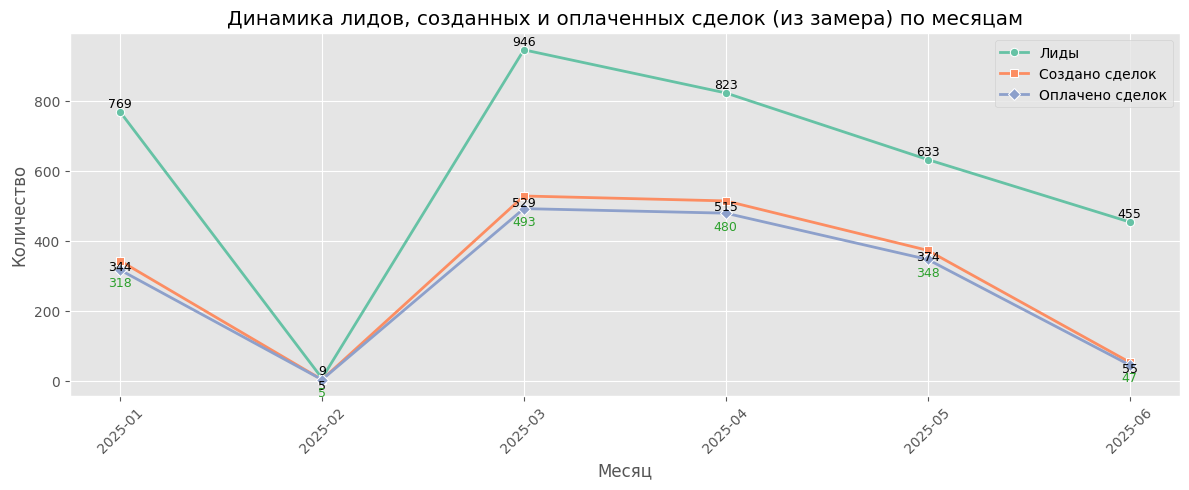

,месяц,количество_лидов,создано_сделок,оплачено_сделок
0,2025-01,769,344,318
1,2025-02,9,5,5
2,2025-03,946,529,493
3,2025-04,823,515,480
4,2025-05,633,374,348
5,2025-06,455,55,47


In [ ]:
# 📌 Фильтрация: лиды из "из замера" с валидной датой создания
zamery_data = data[
    (data['источник_лида'] == 'из замера') &
    (data['время_создания'].notna())
].copy()

# 🗓 Добавляем колонку "месяц"
zamery_data['месяц'] = zamery_data['время_создания'].dt.to_period('M').astype(str)

# ✅ Признак созданной сделки
zamery_data['есть_сделка'] = zamery_data['статус_завершения'] == 'Создана сделка'

# ✅ Признак оплаченной сделки (GMV > 0)
zamery_data['оплачена'] = (zamery_data['есть_сделка']) & (zamery_data['gmv_сделки,_₽'] > 0)

# 📊 Группировка: количество лидов, созданных сделок, оплаченных сделок
monthly_stats = (
    zamery_data
    .groupby('месяц')[['object_id', 'есть_сделка', 'оплачена']]
    .agg(количество_лидов=('object_id', 'count'),
         создано_сделок=('есть_сделка', 'sum'),
         оплачено_сделок=('оплачена', 'sum'))
    .reset_index()
)

# 📈 График с тремя линиями
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_stats,
    x='месяц',
    y='количество_лидов',
    marker='o',
    linewidth=2,
    label='Лиды'
)
sns.lineplot(
    data=monthly_stats,
    x='месяц',
    y='создано_сделок',
    marker='s',
    linewidth=2,
    label='Создано сделок'
)
sns.lineplot(
    data=monthly_stats,
    x='месяц',
    y='оплачено_сделок',
    marker='D',
    linewidth=2,
    label='Оплачено сделок'
)

# 📌 Подписи к точкам
for i, row in monthly_stats.iterrows():
    plt.text(row['месяц'], row['количество_лидов'] + 10,
             f"{row['количество_лидов']}", ha='center', fontsize=9)
    plt.text(row['месяц'], row['создано_сделок'] - 30,
             f"{int(row['создано_сделок'])}", ha='center', fontsize=9)
    plt.text(row['месяц'], row['оплачено_сделок'] - 50,
             f"{int(row['оплачено_сделок'])}", ha='center', fontsize=9, color='tab:green')

# 🧾 Оформление
plt.title("Динамика лидов, созданных и оплаченных сделок (из замера) по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📋 Таблица
display(monthly_stats)


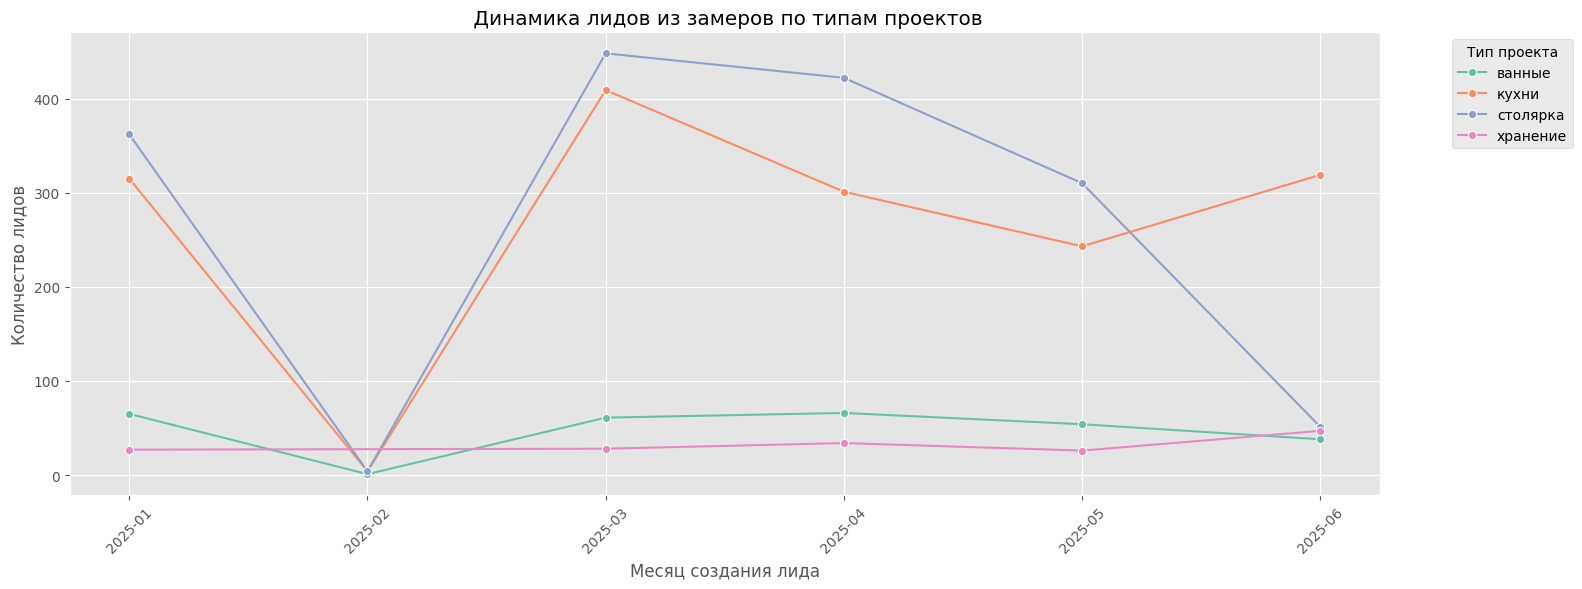

тип_проекта,месяц,ванные,кухни,столярка,хранение
0,2025-01,65.0,315.0,362.0,27.0
1,2025-02,1.0,4.0,4.0,0.0
2,2025-03,61.0,409.0,448.0,28.0
3,2025-04,66.0,301.0,422.0,34.0
4,2025-05,54.0,243.0,310.0,26.0
5,2025-06,38.0,319.0,51.0,47.0


In [ ]:
# 📌 Фильтрация: лиды только из источника "из замера"
zamery_data = data[data['источник_лида'] == 'из замера'].copy()

# 🗓 Добавим колонку "месяц создания"
zamery_data = zamery_data[zamery_data['время_создания'].notna()].copy()
zamery_data['месяц'] = zamery_data['время_создания'].dt.to_period('M').astype(str)

#  Группировка: количество лидов по типу проекта и месяцу
leads_by_month_project = (
    zamery_data
    .groupby(['месяц', 'тип_проекта'])['object_id']
    .count()
    .reset_index()
    .rename(columns={'object_id': 'количество_лидов'})
)

# 📈 Линейный график: динамика лидов по типам проектов
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=leads_by_month_project,
    x='месяц',
    y='количество_лидов',
    hue='тип_проекта',
    marker='o'
)
plt.title(" Динамика лидов из замеров по типам проектов")
plt.xlabel("Месяц создания лида")
plt.ylabel("Количество лидов")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Тип проекта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#  Таблица: количество лидов по месяцам и типам проекта
pivot_table = leads_by_month_project.pivot_table(
    index='месяц',
    columns='тип_проекта',
    values='количество_лидов',
    fill_value=0
).reset_index()

# Показываем таблицу
display(pivot_table)



### 📊 Краткий вывод по лидам из замера

- **Пиковые месяцы**: январь (769 лидов) и март (946 лидов).
- **Февраль** — резкое падение до **9 лидов** — был сбой в системе создания лидов
- Основной объём лидов стабильно дают категории **кухни** и **столярка**:
  - Январь: кухни — 315, столярка — 362.
  - Март: кухни — 409, столярка — 448.
- **Июнь** — падение по всем категориям, особенно по **столярке** (с 310 в мае до 51).
- **Хранение** остаётся на низком, но устойчивом уровне, с небольшим ростом в июне (до 47 лидов).


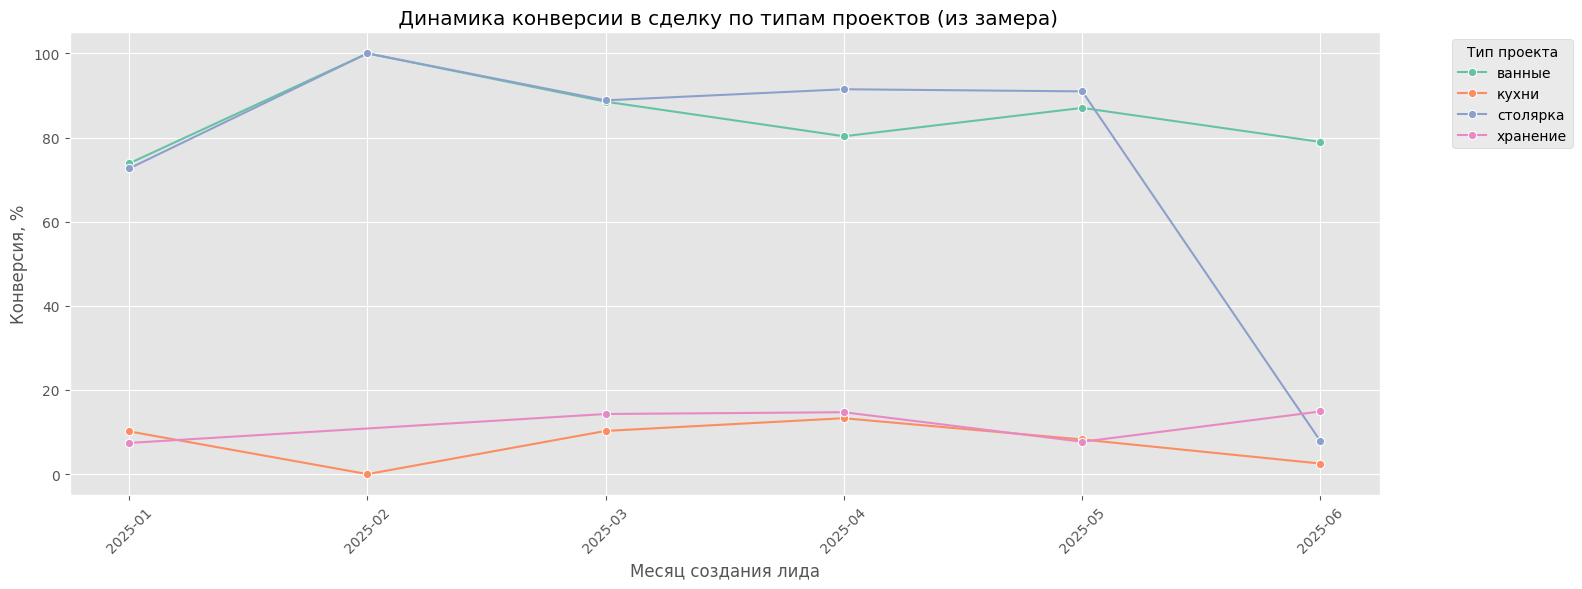

тип_проекта,месяц,ванные,кухни,столярка,хранение
0,2025-01,73.85,10.16,72.65,7.41
1,2025-02,100.00,0.00,100.00,0.00
2,2025-03,88.52,10.27,88.84,14.29
3,2025-04,80.30,13.29,91.47,14.71
4,2025-05,87.04,8.23,90.97,7.69
5,2025-06,78.95,2.51,7.84,14.89


In [ ]:
# 📌 Фильтрация: лиды только из источника "из замера"
zamery_data = data[data['источник_лида'] == 'из замера'].copy()

# 🗓 Добавим колонку "месяц создания"
zamery_data = zamery_data[zamery_data['время_создания'].notna()].copy()
zamery_data['месяц'] = zamery_data['время_создания'].dt.to_period('M').astype(str)

# 🛍 Признак факта покупки
zamery_data['есть_покупка'] = zamery_data['gmv_сделки,_₽'] > 0

#  Группировка по месяцу и типу проекта: считаем конверсию
conversion_by_month_project = (
    zamery_data
    .groupby(['месяц', 'тип_проекта'])['есть_покупка']
    .agg(['count', 'sum'])
    .reset_index()
    .rename(columns={'count': 'всего_лидов', 'sum': 'покупок'})
)

# 💡 Вычисляем конверсию в процентах
conversion_by_month_project['конверсия_%'] = (
    conversion_by_month_project['покупок'] / conversion_by_month_project['всего_лидов'] * 100
).round(2)

#  Линейный график: динамика конверсии по типам проектов
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=conversion_by_month_project,
    x='месяц',
    y='конверсия_%',
    hue='тип_проекта',
    marker='o'
)
plt.title(" Динамика конверсии в сделку по типам проектов (из замера)")
plt.xlabel("Месяц создания лида")
plt.ylabel("Конверсия, %")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Тип проекта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#  Таблица: конверсия по месяцам и типам проекта
pivot_table_conversion = conversion_by_month_project.pivot_table(
    index='месяц',
    columns='тип_проекта',
    values='конверсия_%',
    fill_value=0
).reset_index()

# Показываем таблицу
display(pivot_table_conversion)


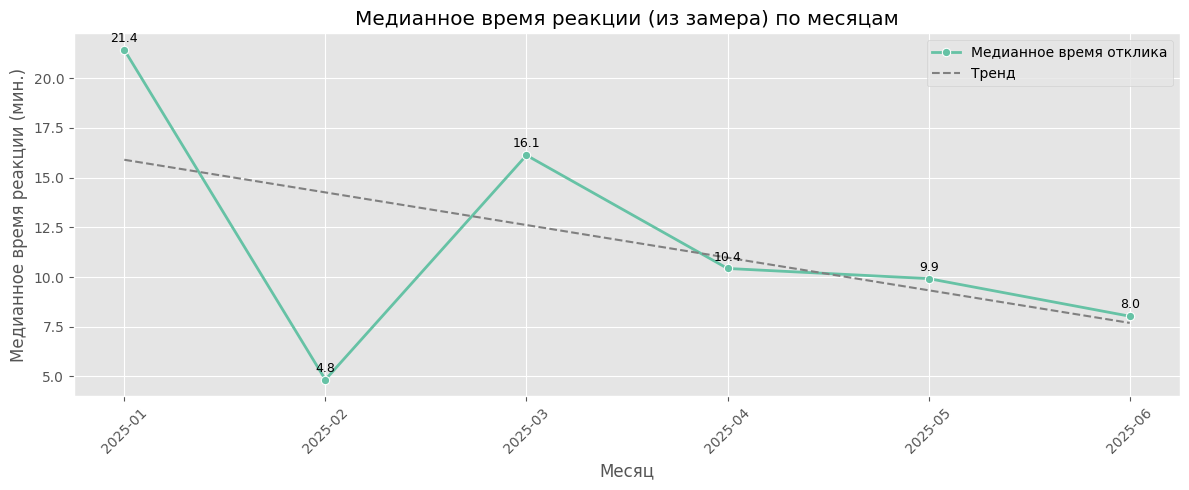

,месяц,медианное_время_реакции
0,2025-01,21.42
1,2025-02,4.84
2,2025-03,16.12
3,2025-04,10.43
4,2025-05,9.92
5,2025-06,8.03


In [ ]:
# 📌 Фильтрация: лиды из "из замера" с валидной датой создания и временем реакции
zamery_data = data[
    (data['источник_лида'] == 'из замера') &
    (data['время_создания'].notna()) &
    (data['реакция_на_лид'].notna()) &
    (data['реакция_на_лид'] > 0)
].copy()

# 🗓 Добавляем колонку "месяц"
zamery_data['месяц'] = zamery_data['время_создания'].dt.to_period('M').astype(str)

# 📊 Считаем медианное время реакции по каждому месяцу
monthly_median_reaction = (
    zamery_data
    .groupby('месяц')['реакция_на_лид']
    .median()
    .reset_index()
    .rename(columns={'реакция_на_лид': 'медианное_время_реакции'})
)

# 📈 Строим график с одной линией и подписями
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_median_reaction,
    x='месяц',
    y='медианное_время_реакции',
    marker='o',
    linewidth=2,
    label='Медианное время отклика'
)

# 🔄 Добавляем значения на график
for i, row in monthly_median_reaction.iterrows():
    plt.text(row['месяц'], row['медианное_время_реакции'] + 0.4,
             f"{row['медианное_время_реакции']:.1f}",
             ha='center', fontsize=9)

# 📉 Добавим линию тренда (линейная регрессия)
import numpy as np
from sklearn.linear_model import LinearRegression

# Преобразуем X в числовой формат
X = np.arange(len(monthly_median_reaction)).reshape(-1, 1)
y = monthly_median_reaction['медианное_время_реакции'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.plot(monthly_median_reaction['месяц'], y_pred, linestyle='--', color='gray', label='Тренд')

# 🧾 Оформление
plt.title("Медианное время реакции (из замера) по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Медианное время реакции (мин.)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📋 Таблица
display(monthly_median_reaction)


# 📊 Промежуточный анализ: динамика лидов и конверсии в сделку (источник — «из замера»)

## 🔹 Кухни
- **Лиды:** максимум — **409** лидов в марте. Минимум — **4** в феврале (возможен сбой в системе или сезонный спад). В июне — рост до **319** лидов.
- **Конверсия:** стабильные ~10% с января по апрель, затем падение — до **2.51%** в июне.
- **Вывод:** несмотря на восстановление объёма лидов, качество трафика или эффективность обработки упали. Требуется ревизия канала.

---

## 🔹 Столярка
- **Лиды:** пик — **448** в марте. Резкий спад после — **51** лида в июне.
- **Конверсия:** высокие значения до мая (**~90%**), затем обвал — **7.84%** в июне.
- **Вывод:** резкое падение как интереса, так и качества лидов. Необходимо проверить причину снижения эффективности после марта.

---

## 🔹 Ванные
- **Лиды:** относительно стабильные значения (от **38** до **66** лидов). Пик — в апреле (**66**), минимум — в июне (**38**).
- **Конверсия:** consistently высокая — **от 73% до 100%** в разные месяцы.
- **Вывод:** проект стабильно конвертирует, несмотря на сокращение лидов. Можно масштабировать при наличии ресурса.

---

## 🔹 Хранение
- **Лиды:** от **0** в феврале до **47** в июне. Рост после февраля — устойчивый.
- **Конверсия:** низкая, но растущая — от **0%** в феврале до **14.89%** в июне.
- **Вывод:** направление демонстрирует устойчивый рост и улучшение эффективности. Потенциал для дальнейшего развития.

---

## 🟢 Общие выводы
- **Февраль** — провальный месяц по всем направлениям (возможно, технические сбои или спад активности).
- **Март** — пик активности: лиды и конверсии максимально высоки.
- **Июнь**:
  - Кухни — объём лидов восстанавливается, но резко просела конверсия.
  - Столярка — упали и лиды, и конверсия.
  - Хранение — показывает положительную динамику.
  - Ванные — удерживают высокую эффективность.

📌 **Рекомендации:**
- Анализировать причины спада в феврале и падения конверсии по «кухням» и «столярке» в июне.
- Поддержать рост «хранения», а «ванные» — масштабировать.


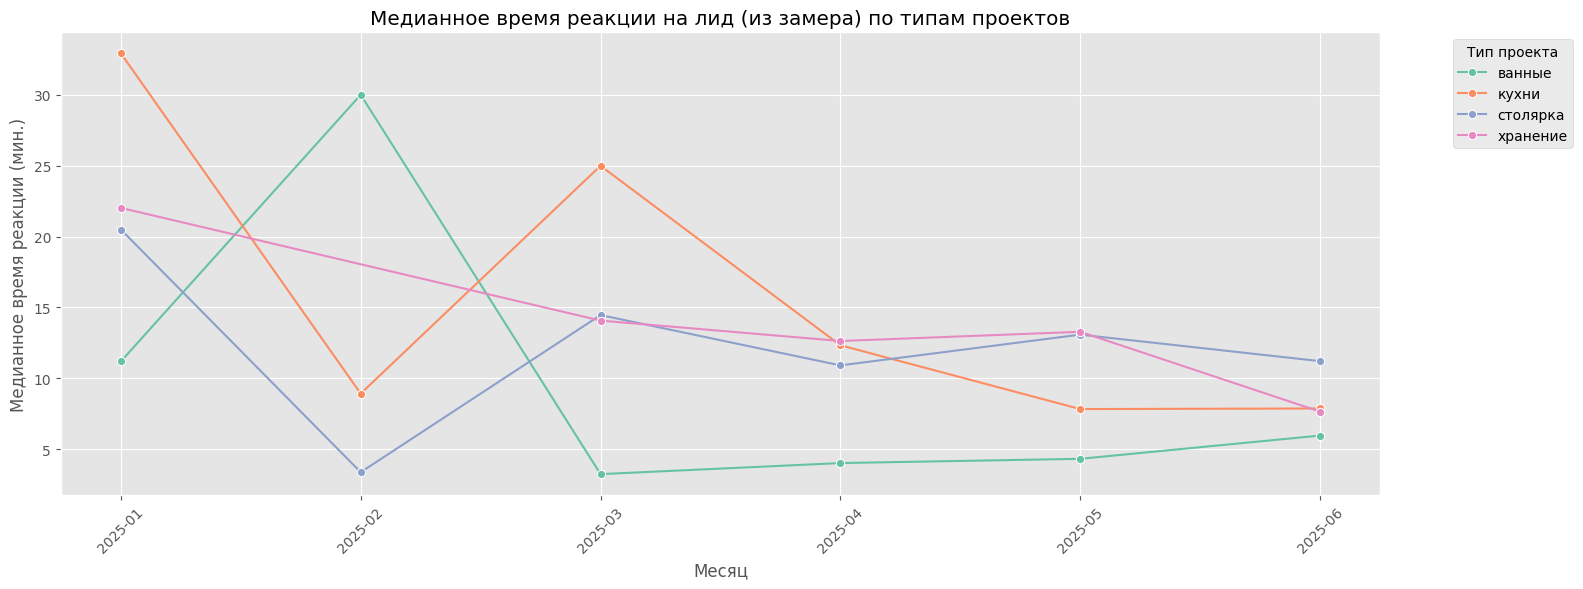

тип_проекта,месяц,ванные,кухни,столярка,хранение
0,2025-01,11.19,32.92,20.495,22.02
1,2025-02,30.00,8.92,3.375,0.00
2,2025-03,3.24,24.99,14.460,14.07
3,2025-04,4.02,12.33,10.910,12.63
4,2025-05,4.32,7.83,13.080,13.28
5,2025-06,5.96,7.87,11.210,7.65


In [ ]:
# 📌 Фильтрация: лиды только из источника "из замера" с валидной реакцией
zamery_data = data[
    (data['источник_лида'] == 'из замера') &
    (data['время_создания'].notna()) &
    (data['реакция_на_лид'].notna()) &
    (data['реакция_на_лид'] > 0)
].copy()

# 🗓 Добавим колонку "месяц создания"
zamery_data['месяц'] = zamery_data['время_создания'].dt.to_period('M').astype(str)

# 📊 Группировка: медианное время реакции по типу проекта и месяцу
reaction_by_month_project = (
    zamery_data
    .groupby(['месяц', 'тип_проекта'])['реакция_на_лид']
    .median()
    .reset_index()
    .rename(columns={'реакция_на_лид': 'медианное_время_реакции'})
)

# 📈 График: динамика времени реакции по проектам
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=reaction_by_month_project,
    x='месяц',
    y='медианное_время_реакции',
    hue='тип_проекта',
    marker='o'
)
plt.title("Медианное время реакции на лид (из замера) по типам проектов")
plt.xlabel("Месяц")
plt.ylabel("Медианное время реакции (мин.)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Тип проекта", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 📋 Таблица: медианное время реакции по месяцам и типам проекта
pivot_table_reaction = reaction_by_month_project.pivot_table(
    index='месяц',
    columns='тип_проекта',
    values='медианное_время_реакции',
    fill_value=0
).reset_index()

display(pivot_table_reaction)
